# both merfish and barseq imputation on pseudoclusters
- compute the confidence score 

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import processing



# prepare data (adata and arc info) 
## 1. load adata_sc

In [2]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_d4_barseq_2k.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

In [3]:
adata_sc.shape

(4895, 2251)

## 2. load adata_mer

In [4]:
# this is just to subset the cells!
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
mercell_index = adata_mer.obs['leiden']!='5'

In [5]:

adata_mer = adata_mer[mercell_index,:]
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
print(adata_mer.X.max(),np.sum(adata_mer.X, 1))# do not normalize again. these are batch corrected counts 

0.22035266 [0.9999443  0.9999371  0.99994504 ... 0.9999274  0.99983954 0.9998051 ]


In [6]:
adata_mer.shape

(2252, 314)

## 3. load barseq as anndata

In [7]:
datapath = '/home/shuonan.chen/scratch_shuonan/scripts/LC_NE_dataintegration/BARseq/data/LCNE_barseq_counts_updated.csv'
df = pd.read_csv(datapath)  #df.iloc[:,0]
df.head()

,Unnamed: 0,5_17_380460,5_17_380518,5_17_380548,5_17_380660,5_17_380687,5_17_380704,5_17_380789,5_17_380809,5_17_380872,...,1_4_1720744,1_4_1720974,1_4_1721061,1_4_1721074,1_4_1721267,1_4_1721407,1_4_1850646,1_4_1850698,1_4_1850751,1_4_1850785
0,Abcb7,9,0,5,4,0,9,1,14,2,...,3,1,0,1,2,1,2,0,2,0
1,Abtb3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Adamtsl2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Aldoa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Aldoc,0,0,1,1,0,0,0,0,0,...,0,1,0,1,1,1,0,1,0,1


In [8]:
adata_bar = anndata.AnnData(df.iloc[:,1:].T)
adata_bar.var_names = df.iloc[:,0]
adata_bar.shape
adata_bar.X.shape

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


(3442, 103)

In [9]:
adata_bar

AnnData object with n_obs × n_vars = 3442 × 103

### BARseq data, load the cell position data

In [10]:
# filname = '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/data/LCNE_barseq_cell_positions.csv'
filname = '/home/shuonan.chen/scratch_shuonan/scripts/LC_NE_dataintegration/BARseq/data/metadata_LCNE_barseq_counts_updated.csv'
df = pd.read_csv(filname)
df.head()

,Unnamed: 0,slice,barcode,uid,CCF_DV,CCF_ML,louvain_cluster
0,5_17_380460,17,0,5_17_380460,183.026557,185.603010,1
1,5_17_380518,17,1,5_17_380518,177.716705,186.262665,2
2,5_17_380548,17,1,5_17_380548,176.795441,187.163641,1
3,5_17_380660,17,0,5_17_380660,171.708297,189.205095,1
4,5_17_380687,17,0,5_17_380687,180.587447,190.182430,2


In [11]:
df.shape

(3442, 7)

In [12]:
all_in_index = df['uid'].isin(adata_bar.obs.index).all()
print("All df cell_ids in adata_bar.obs.index?", all_in_index)
missing = df.loc[~df['uid'].isin(adata_bar.obs.index), 'uid']
print("Missing cell_ids:", missing.tolist())


All df cell_ids in adata_bar.obs.index? True
Missing cell_ids: []


In [13]:

obs_df = (adata_bar.obs
    .reset_index()                     # brings the index into 'index'
    .rename(columns={'index':'uid'}))

df_merged = df.merge(obs_df,on='uid',how='left')


### optional: only keep the yes/no barcode cells

## 4. take common genes

#### ( optionally we get the original HVG list )

In [14]:
common_genes_mer = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
common_genes_bar = np.intersect1d(adata_bar.var_names, adata_sc.var_names)
common_genes_mer.shape,common_genes_bar.shape

((314,), (102,))

In [15]:
common_genes_ALL = np.intersect1d(adata_bar.var_names, adata_mer.var_names)
common_genes_ALL.shape

(19,)

In [16]:
adata_mer = adata_mer[:,common_genes_mer]
adata_bar = adata_bar[:,common_genes_bar]
adata_mer.shape, adata_bar.shape

((2252, 314), (3442, 102))

# find NN based on rank based simialrity

In [17]:
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
from pseudocluster_imputations import *

In [18]:
k = 100
imp_mer,conf_mer = impute_pseudocluster(adata_mer, adata_sc,k=k)
imp_bar,conf_bar = impute_pseudocluster(adata_bar, adata_sc,k=k)

using 314 genes to run the imputations!
using 102 genes to run the imputations!


In [19]:
conf_bar.keys()

dict_keys(['confidence_scores', 'confidence_vals', 'frac_vals', 'pscores'])

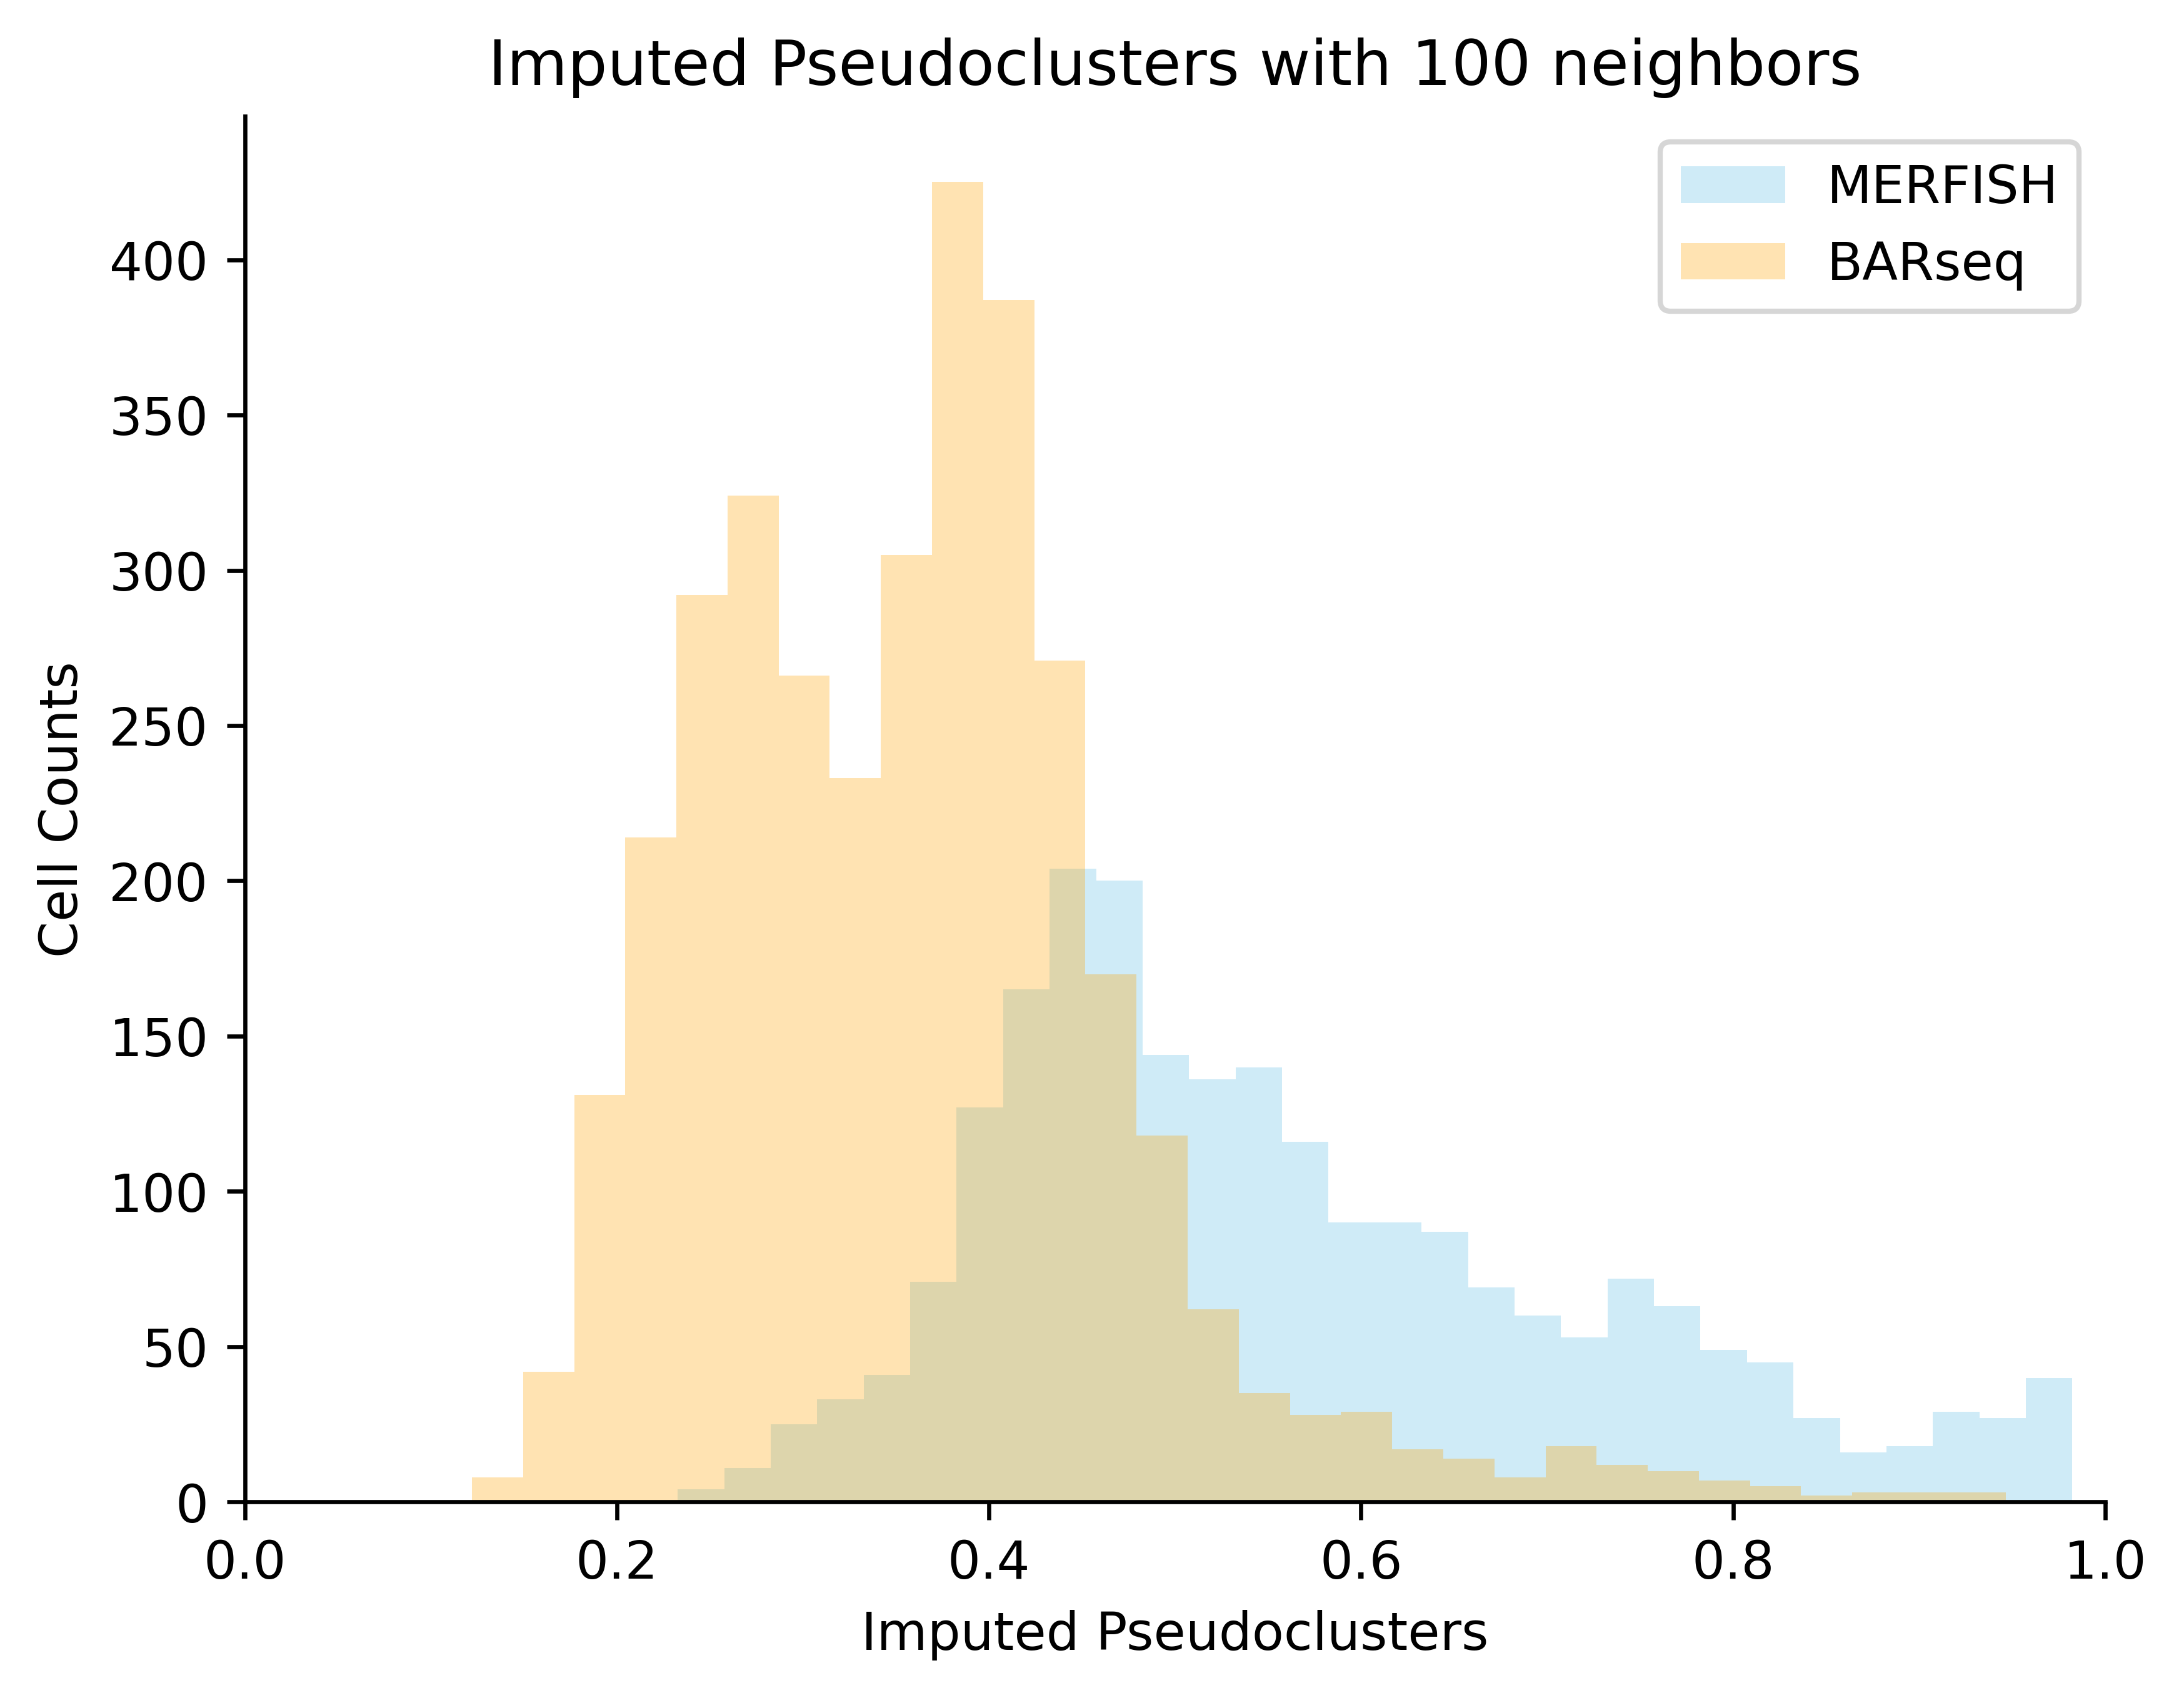

In [20]:
plt.hist(imp_mer, bins = 30,alpha = .4, label = 'MERFISH',color = 'skyblue');
plt.hist(imp_bar, bins = 30,alpha = .3,label = 'BARseq',color = 'orange');
plt.legend()
plt.xlim(0,1)
plt.title(f'Imputed Pseudoclusters with {k} neighbors')
plt.ylabel('Cell Counts')
plt.xlabel('Imputed Pseudoclusters')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gcf().set_dpi(600)

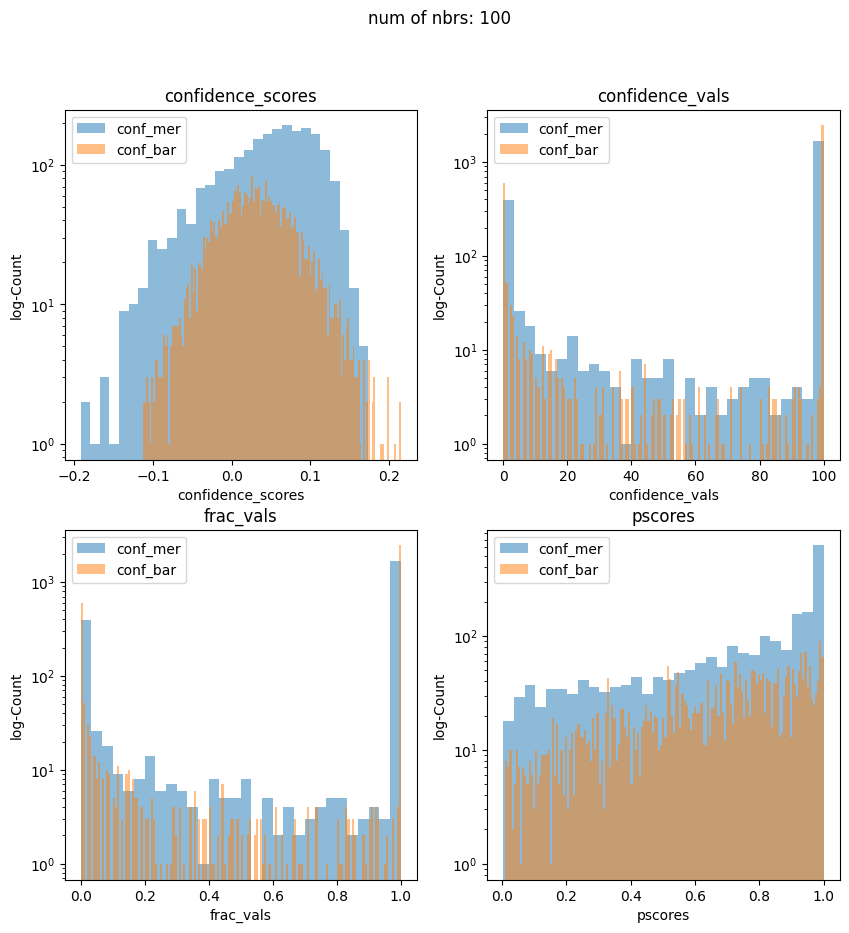

In [21]:
plt.figure(figsize = (10,10))
for i,key in enumerate(conf_mer.keys()):
    plt.subplot(2,2,i+1)
    plt.hist(conf_mer[key], bins=30, alpha=0.5, label=f'conf_mer')
    plt.hist(conf_bar[key], bins=150, alpha=0.5, label=f'conf_bar')
    plt.title(key)
    plt.xlabel(key)
    plt.yscale('log')
    plt.ylabel('log-Count')
    plt.legend()
plt.suptitle(f'num of nbrs: {k}')
plt.show()

# barseq imputed 

In [22]:
adata_bar.obs['confidence_power'] = conf_bar['pscores']
adata_bar.obs['imputed pseudocluster'] = imp_bar
adata_bar.obs['conf_bool'] =  conf_bar['confidence_scores']>0
adata_bar.obs['conf_scores'] =  conf_bar['confidence_scores']

df_merged['imputed pseudocluster'] = imp_bar
df_merged['confidence_power'] = conf_bar['pscores']

/scratch/fast/1595211/ipykernel_577417/44254203.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_bar.obs['confidence_power'] = conf_bar['pscores']


In [23]:
adata_mer.obs['confidence_power'] = conf_mer['pscores']
adata_mer.obs['imputed pseudocluster'] = imp_mer
adata_mer.obs['conf_bool'] =  conf_mer['confidence_scores']>0
adata_mer.obs['conf_scores'] =  conf_mer['confidence_scores']


/scratch/fast/1595211/ipykernel_577417/3535591151.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mer.obs['confidence_power'] = conf_mer['pscores']


In [24]:
print(f'confident cells in BARseq:',  np.around(adata_bar.obs['conf_bool'].sum()/adata_bar.shape[0],3))
print(f'confident cells in MERFISH:',  np.around(adata_mer.obs['conf_bool'].sum()/adata_mer.shape[0],3))

confident cells in BARseq: 0.745
confident cells in MERFISH: 0.775


Text(0, 0.5, 'confidence_power')

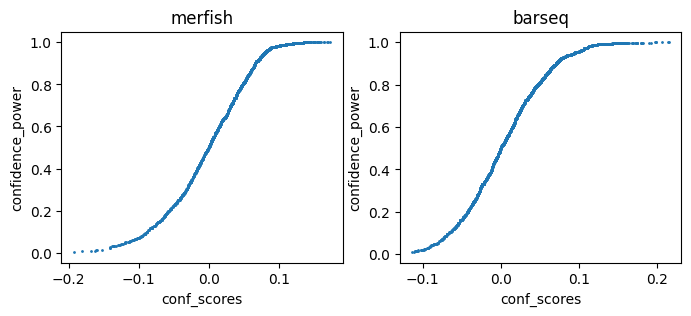

In [25]:
ke = ['conf_scores','confidence_power']
plt.figure(figsize = (8,3))
plt.subplot(1,2,1);
plt.scatter(adata_mer.obs[ke[0]],adata_mer.obs[ke[1]], s=1);
plt.title('merfish')
plt.xlabel(ke[0]);plt.ylabel(ke[1])
plt.subplot(1,2,2);
plt.scatter(adata_bar.obs[ke[0]],adata_bar.obs[ke[1]], s=1);
plt.title('barseq')
plt.xlabel(ke[0]);plt.ylabel(ke[1])

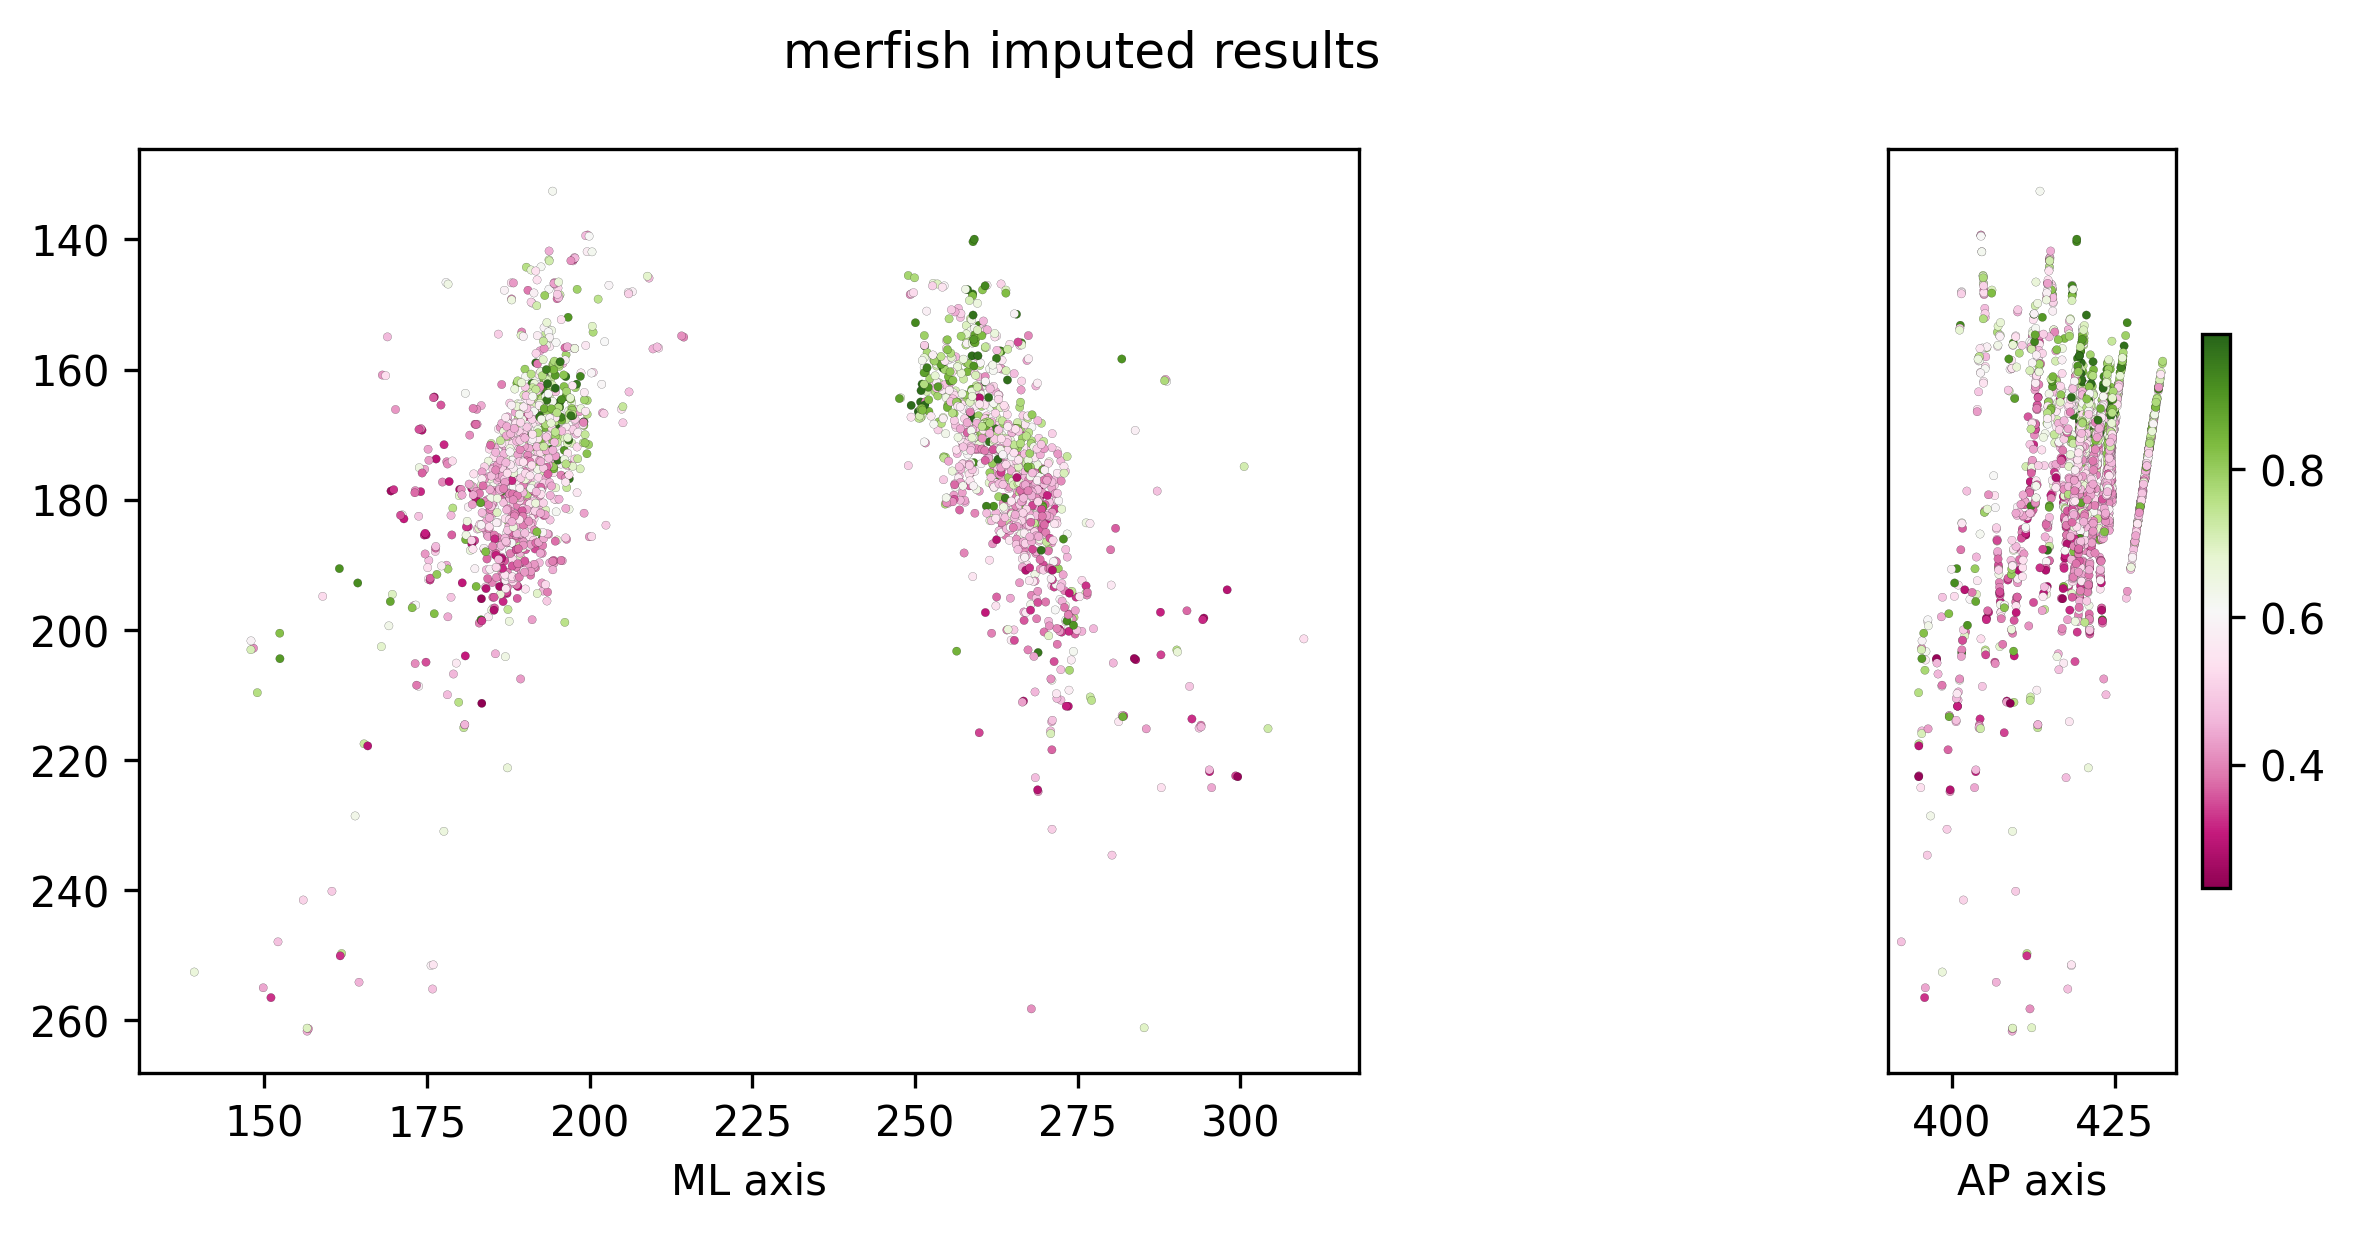

In [26]:
fig, axes = plt.subplots(1,2,figsize=(10,4),gridspec_kw={'width_ratios': [3,1]})
ax = axes[0]
sca = ax.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1],
            c=adata_mer.obs['imputed pseudocluster'], edgecolor='k',linewidth = 0.04,cmap = 'PiYG',s=4)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_xlabel('ML axis')
ax = axes[1]
sca = ax.scatter(adata_mer.obsm['spatial'][:,0],adata_mer.obsm['spatial'][:,1],
            c=adata_mer.obs['imputed pseudocluster'], edgecolor='k',linewidth = 0.04,cmap = 'PiYG',s=4)
fig.colorbar(sca, ax = ax,shrink = .6)
ax.set_aspect('equal')
ax.set_yticks([])
ax.invert_yaxis()
ax.set_xlabel('AP axis')
plt.suptitle("merfish imputed results")
plt.gcf().set_dpi(300)


Text(0, 0.5, 'imputed pc')

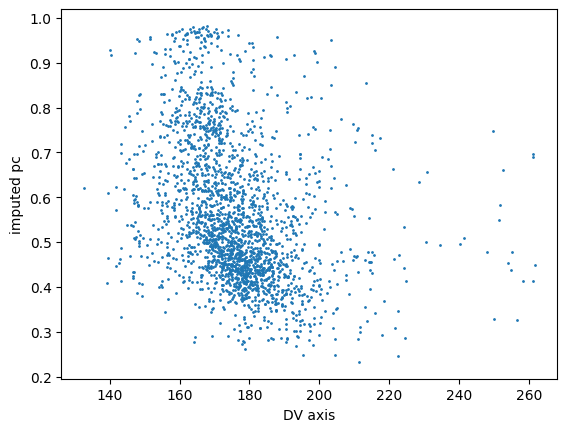

In [27]:
plt.scatter(adata_mer.obsm['spatial'][:,1], imp_mer,s=1)
plt.xlabel('DV axis')
plt.ylabel('imputed pc')


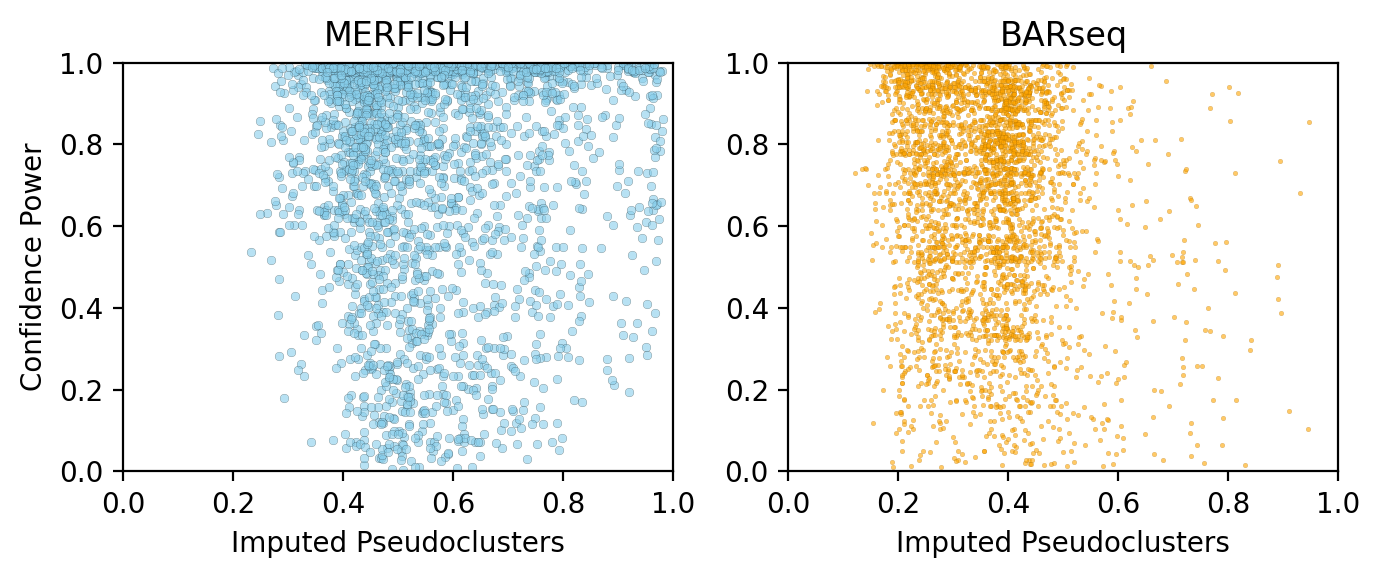

In [28]:
ke = ['imputed pseudocluster','confidence_power']
plt.figure(figsize = (7,3))
plt.subplot(1,2,1);
plt.scatter(adata_mer.obs[ke[0]],adata_mer.obs[ke[1]], s=10, alpha = .6,
            color = 'skyblue', edgecolor = 'k', linewidth = .1);
plt.title('MERFISH')
plt.xlim(0,1);plt.ylim(0,1)
plt.xlabel('Imputed Pseudoclusters');
plt.ylabel('Confidence Power')

plt.subplot(1,2,2);
plt.scatter(adata_bar.obs[ke[0]],adata_bar.obs[ke[1]], s=3, alpha = .6,
            color = 'orange', edgecolor = 'k', linewidth = .04);
plt.title('BARseq')
plt.xlim(0,1);plt.ylim(0,1)
plt.xlabel('Imputed Pseudoclusters');
plt.tight_layout()

plt.gcf().set_dpi(200)

Text(0, 0.5, 'Confidence Power')

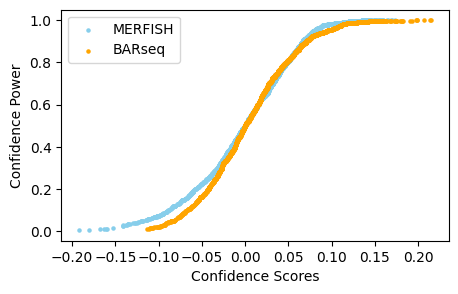

In [29]:
ke = ['conf_scores','confidence_power']
plt.figure(figsize = (5,3))
plt.scatter(adata_mer.obs[ke[0]],adata_mer.obs[ke[1]], s=5,label = 'MERFISH', color = 'skyblue');
plt.scatter(adata_bar.obs[ke[0]],adata_bar.obs[ke[1]], s=5, label = 'BARseq', color = 'orange');
plt.legend()
plt.xlabel('Confidence Scores');plt.ylabel('Confidence Power')
# plt.gcf().set_dpi(w00)

Text(0.5, 0.98, 'barseq results!')

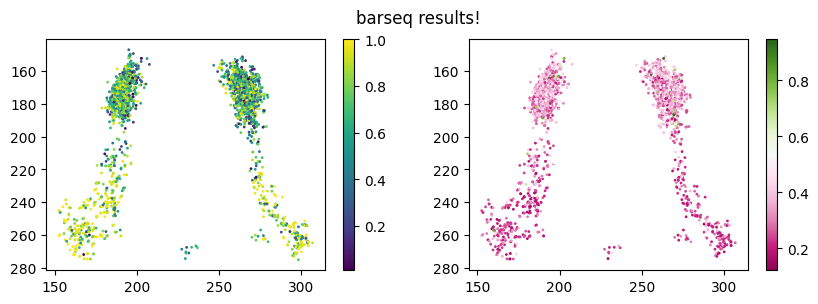

In [30]:
plt.figure(figsize = (10,3))

plt.subplot(1,2,1);
plt.scatter(df_merged['CCF_ML'],df_merged['CCF_DV'], c=df_merged['confidence_power'], s=1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.colorbar()

plt.subplot(1,2,2);
plt.scatter(df_merged['CCF_ML'],df_merged['CCF_DV'], 
            c=df_merged['imputed pseudocluster'],
            cmap ='PiYG', s=1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.colorbar()
plt.suptitle('barseq results!')

Text(0.5, 0.98, 'MERFISH results!')

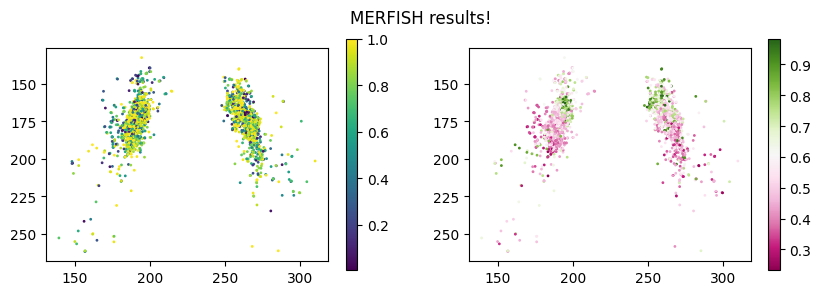

In [31]:
plt.figure(figsize = (10,3))
plt.subplot(1,2,1);
plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1],c=conf_mer['pscores'], s=1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.colorbar()

plt.subplot(1,2,2);
plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1],
            c=imp_mer,cmap ='PiYG', s=1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.colorbar()
plt.suptitle('MERFISH results!')

Text(0.5, 1.0, 'merfish, colored by confidence power')

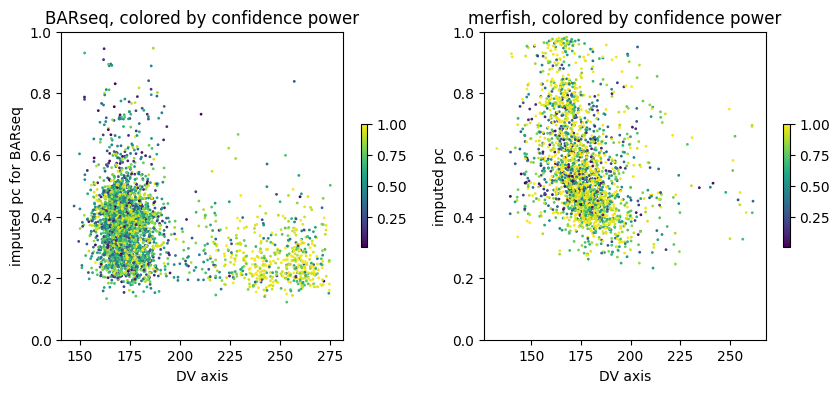

In [32]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.scatter(df_merged['CCF_DV'], df_merged['imputed pseudocluster'],s=1, c=conf_bar['pscores'])
plt.colorbar(shrink= .4)
plt.ylim(0,1)
plt.xlabel('DV axis')
plt.ylabel('imputed pc for BARseq')
plt.title('BARseq, colored by confidence power')


plt.subplot(1,2,2)
plt.scatter(adata_mer.obsm['spatial'][:,1], imp_mer,s=1,c=conf_mer['pscores'])
plt.colorbar(shrink= .4)
plt.ylim(0,1)
plt.xlabel('DV axis')
plt.ylabel('imputed pc')
plt.title('merfish, colored by confidence power')

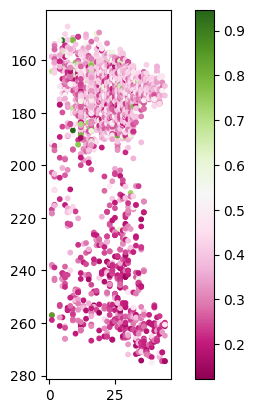

In [33]:

plt.scatter(df_merged['slice'],df_merged['CCF_DV'], 
            c=df_merged['imputed pseudocluster'],
            cmap ='PiYG',  s=10)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.colorbar()

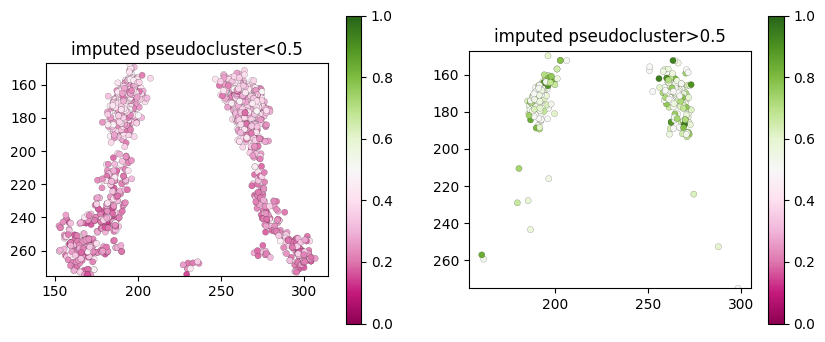

In [34]:
threfoo = 0.5
plt.figure(figsize = (10,4))
mask = df_merged['imputed pseudocluster']<threfoo
plt.subplot(1,2,1)
plt.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask], 
            c=df_merged['imputed pseudocluster'][mask],vmin =0,vmax = 1,
            cmap ='PiYG',  s=20, edgecolor='k', linewidth = .1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.ylim(df_merged['CCF_DV'].max(),df_merged['CCF_DV'].min())
plt.title(f'imputed pseudocluster<{threfoo}')
plt.colorbar()

mask = df_merged['imputed pseudocluster']>threfoo
plt.subplot(1,2,2)
plt.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask], 
            c=df_merged['imputed pseudocluster'][mask],vmin =0,vmax = 1,
            cmap ='PiYG',  s=20, edgecolor='k', linewidth = .1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.ylim(df_merged['CCF_DV'].max(),df_merged['CCF_DV'].min())
plt.title(f'imputed pseudocluster>{threfoo}')
plt.colorbar()

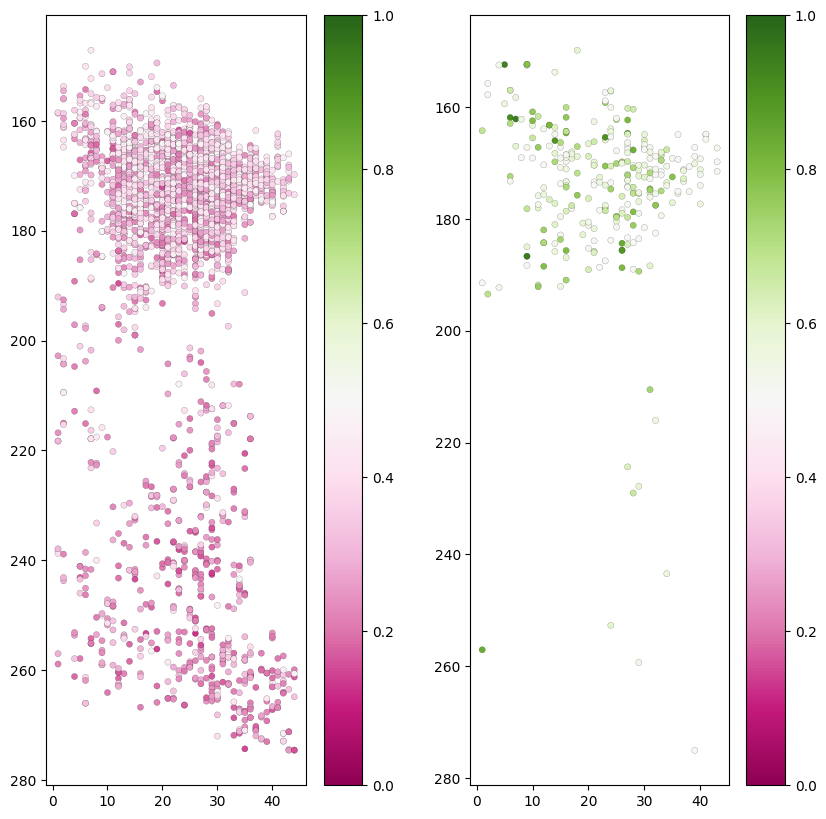

In [38]:
plt.figure(figsize = (10,10))
mask = df_merged['imputed pseudocluster']<0.5
plt.subplot(1,2,1)
plt.scatter(df_merged['slice'][mask],df_merged['CCF_DV'][mask], 
            c=df_merged['imputed pseudocluster'][mask],vmin =0,vmax = 1,
            cmap ='PiYG',  s=20, edgecolor='k', linewidth = .1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.colorbar()

mask = df_merged['imputed pseudocluster']>0.5
plt.subplot(1,2,2)
plt.scatter(df_merged['slice'][mask],df_merged['CCF_DV'][mask], 
            c=df_merged['imputed pseudocluster'][mask],vmin =0,vmax = 1,
            cmap ='PiYG',  s=20, edgecolor='k', linewidth = .1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.colorbar()

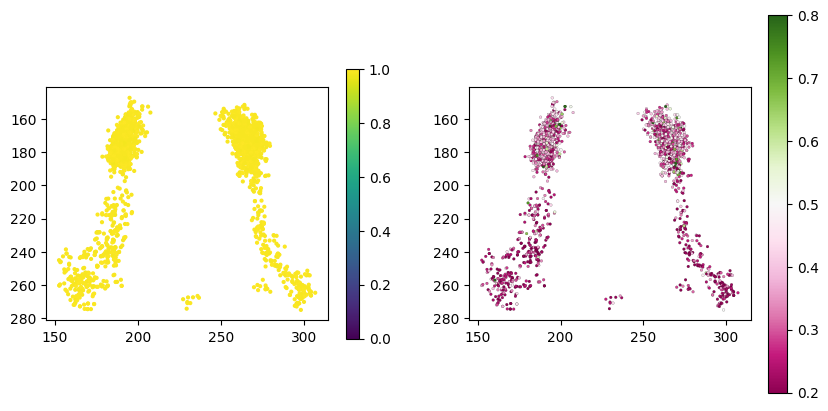

In [39]:
s = 4
mask = df_merged['confidence_power'].values>0.8
plt.figure(figsize= (10, 7))
plt.subplot(1,2,1)
plt.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask],vmin = 0, vmax = 1,
            c=df_merged['confidence_power'][mask], s=s)
plt.gca().set_aspect('equal');plt.gca().invert_yaxis()
plt.colorbar(shrink = .5)
plt.subplot(1,2,2)
plt.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask],vmin = 0.2, vmax = 0.8,
            c=df_merged['imputed pseudocluster'][mask], s=s, 
            edgecolor = 'k', linewidth =0.1, cmap ='PiYG')
plt.gca().set_aspect('equal');plt.gca().invert_yaxis()
plt.colorbar(shrink = .7)

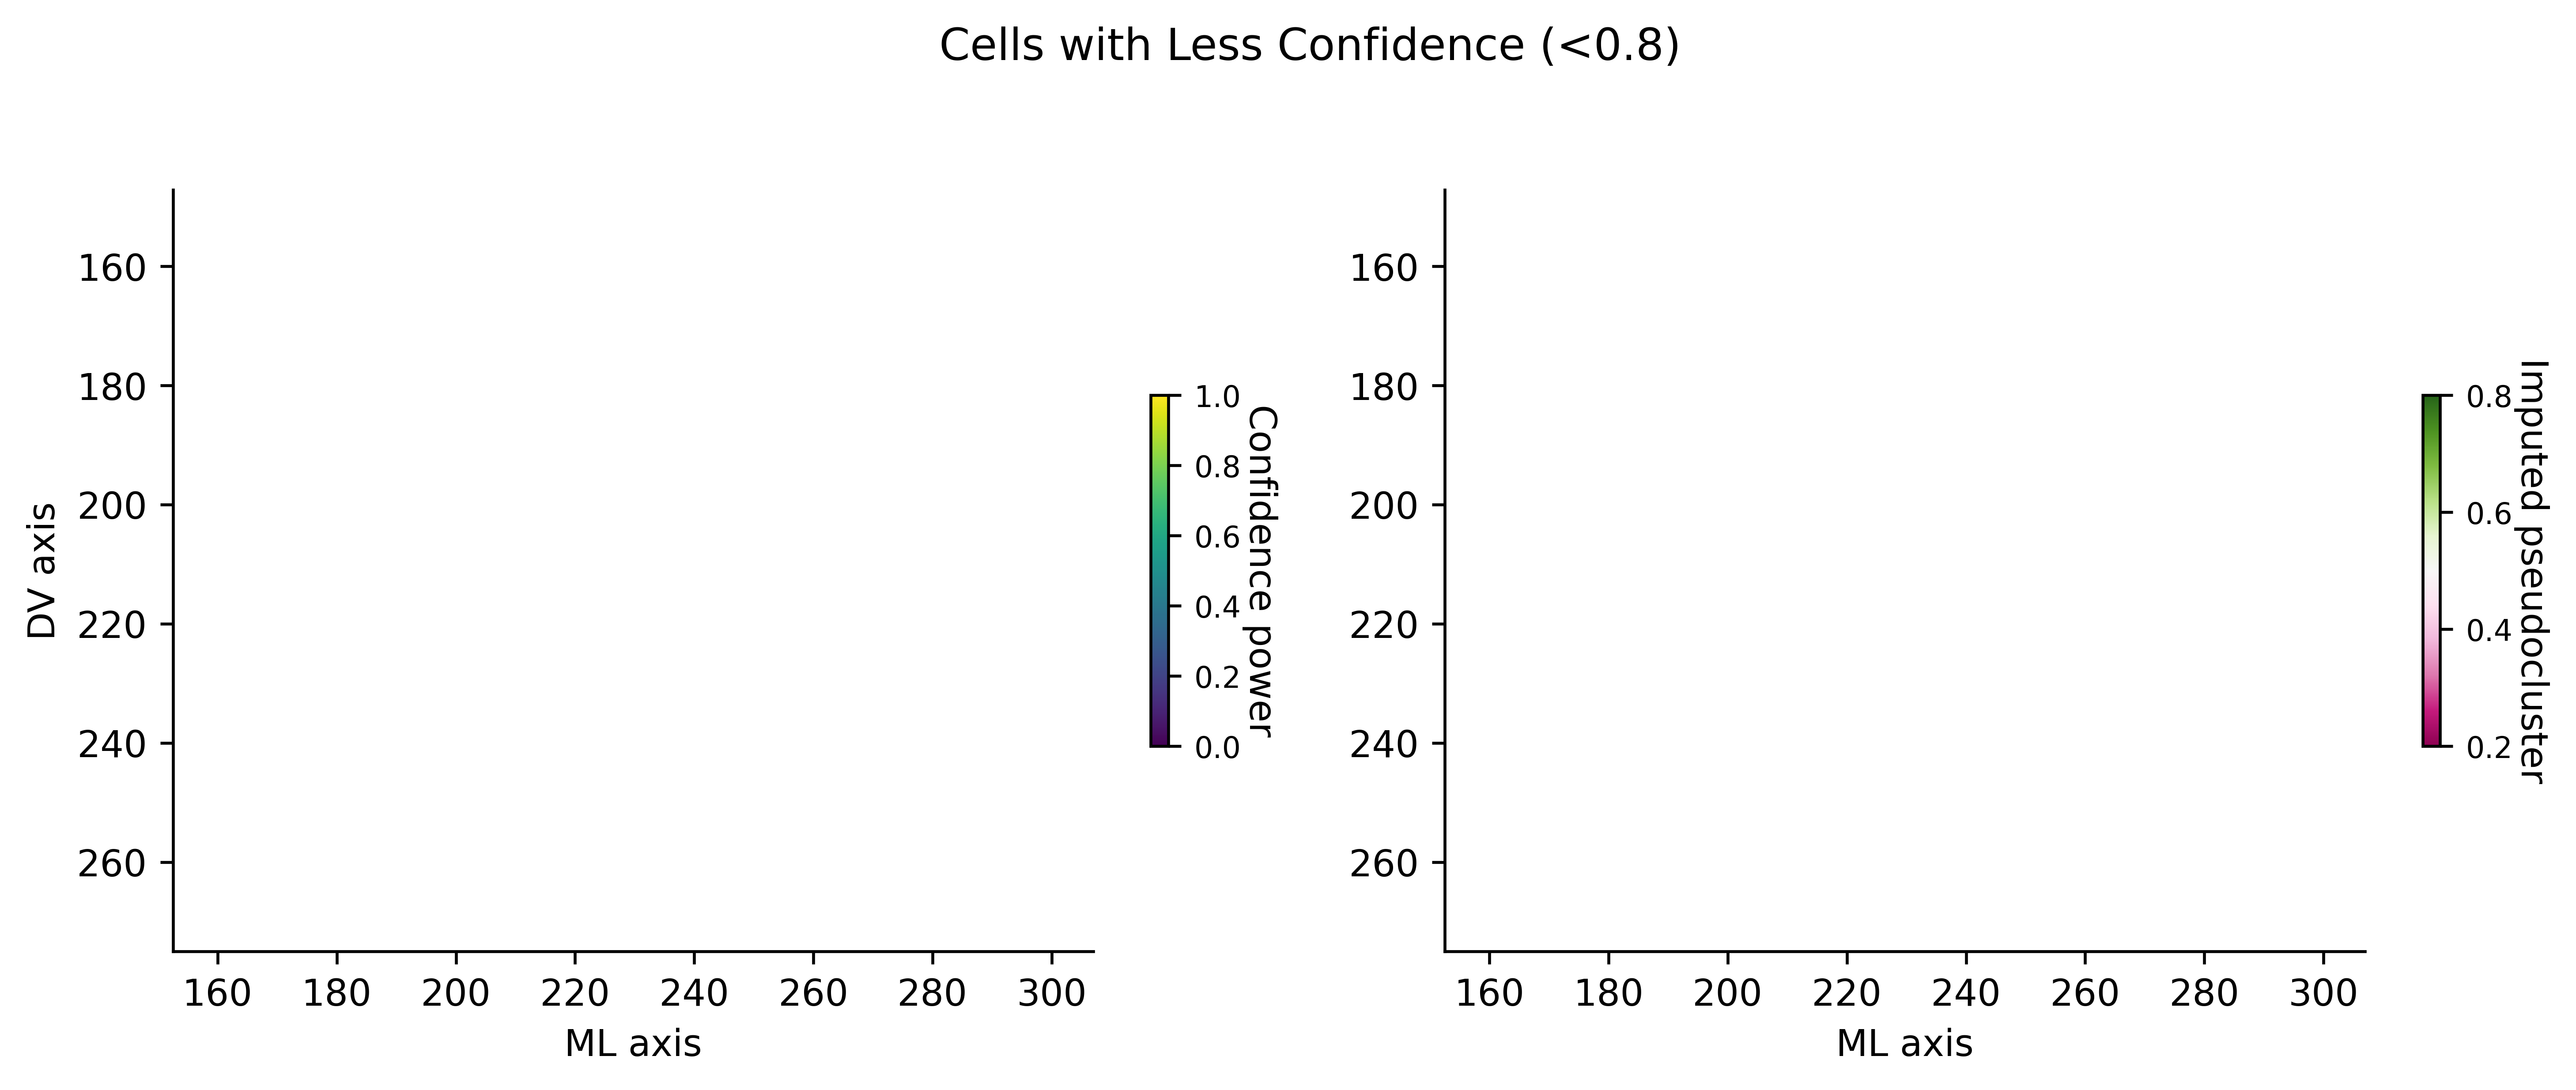

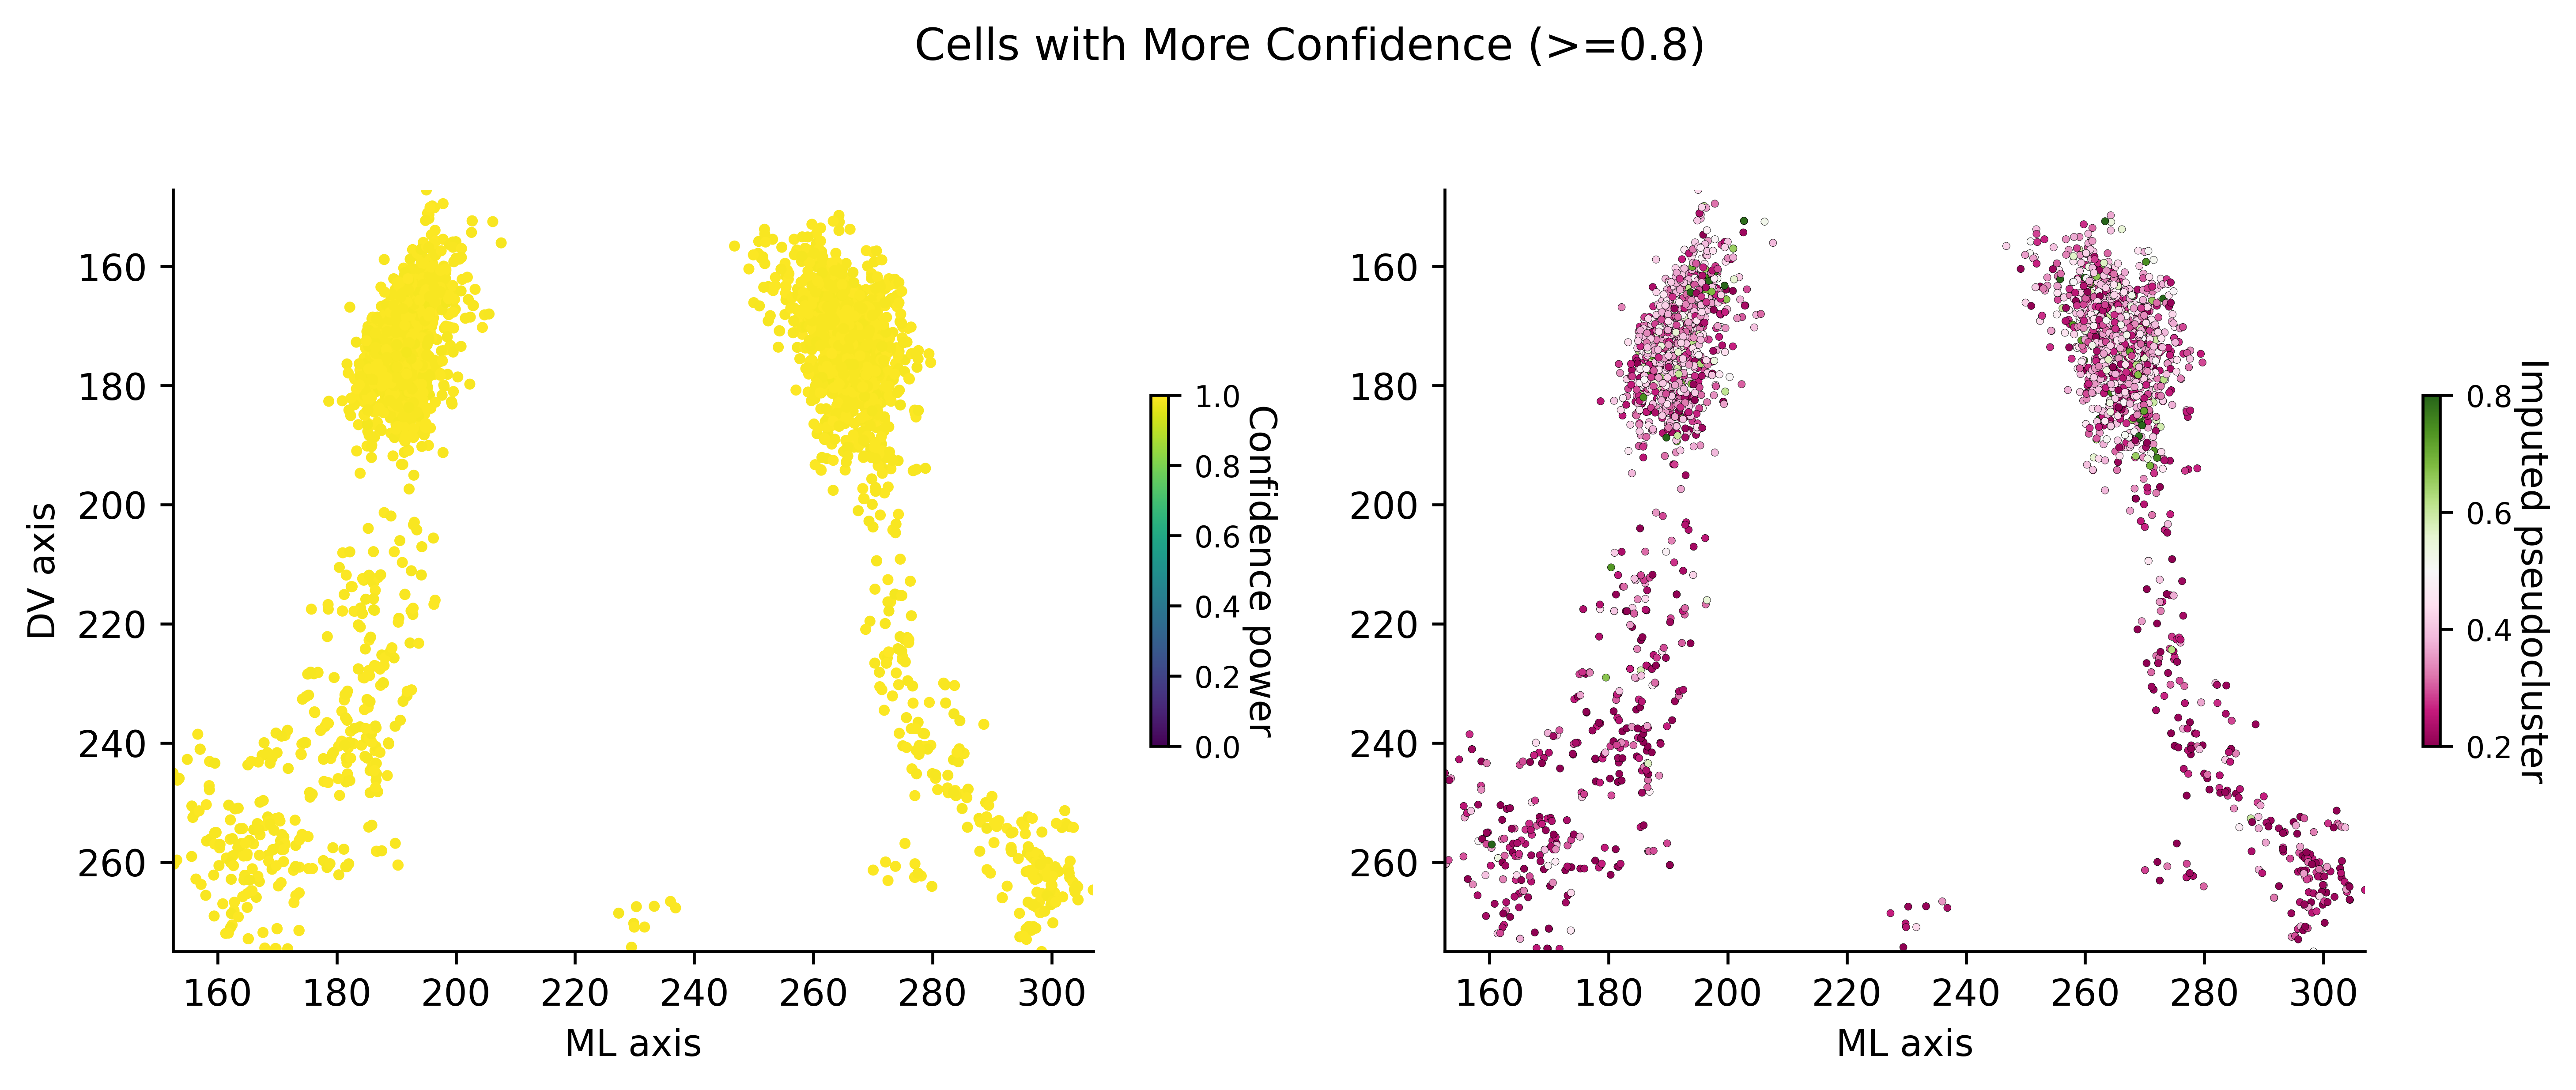

In [40]:
s = 4
conf_thre = 0.8
mask = df_merged['confidence_power'].values<conf_thre
plt.figure(figsize=(10,4))
ax = plt.subplot(1,2,1)
sc1 = ax.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask],
                 c=df_merged['confidence_power'][mask],vmin=0, vmax=1, s=s)
ax.set_aspect('equal');ax.invert_yaxis()
cb1 = plt.colorbar(sc1, shrink=.4, ax=ax)
cb1.set_label('Confidence power', rotation=270, labelpad=10)
cb1.ax.tick_params(labelsize=8) 
ax.set_xlabel('ML axis')
ax.set_ylabel('DV axis')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(df_merged['CCF_ML'].min(),df_merged['CCF_ML'].max())
ax.set_ylim(df_merged['CCF_DV'].max(),df_merged['CCF_DV'].min())


ax = plt.subplot(1,2,2)
sc2 = ax.scatter(df_merged['CCF_ML'][mask],
                 df_merged['CCF_DV'][mask],
                 c=df_merged['imputed pseudocluster'][mask],
                 vmin=0.2, vmax=0.8, s=s,
                 edgecolor='k', linewidth=0.1, cmap='PiYG')
ax.set_aspect('equal')
ax.invert_yaxis()
cb2 = plt.colorbar(sc2, shrink=.4, ax=ax)
cb2.set_label('Imputed pseudocluster', rotation=270, labelpad=10)
cb2.ax.tick_params(labelsize=8) 
ax.set_xlabel('ML axis')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(df_merged['CCF_ML'].min(),df_merged['CCF_ML'].max())
ax.set_ylim(df_merged['CCF_DV'].max(),df_merged['CCF_DV'].min())

plt.suptitle(f'Cells with Less Confidence (<{conf_thre})')
plt.tight_layout()
plt.gcf().set_dpi(600)

mask = df_merged['confidence_power'].values>conf_thre
plt.figure(figsize=(10,4))
ax = plt.subplot(1,2,1)
sc1 = ax.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask],
                 c=df_merged['confidence_power'][mask],vmin=0, vmax=1, s=s)
ax.set_aspect('equal');ax.invert_yaxis()
cb1 = plt.colorbar(sc1, shrink=.4, ax=ax)
cb1.set_label('Confidence power', rotation=270, labelpad=10)
cb1.ax.tick_params(labelsize=8) 
ax.set_xlabel('ML axis')
ax.set_ylabel('DV axis')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(df_merged['CCF_ML'].min(),df_merged['CCF_ML'].max())
ax.set_ylim(df_merged['CCF_DV'].max(),df_merged['CCF_DV'].min())


ax = plt.subplot(1,2,2)
sc2 = ax.scatter(df_merged['CCF_ML'][mask],
                 df_merged['CCF_DV'][mask],
                 c=df_merged['imputed pseudocluster'][mask],
                 vmin=0.2, vmax=0.8, s=s,
                 edgecolor='k', linewidth=0.1, cmap='PiYG')
ax.set_aspect('equal')
ax.invert_yaxis()
cb2 = plt.colorbar(sc2, shrink=.4, ax=ax)
cb2.set_label('Imputed pseudocluster', rotation=270, labelpad=10)
cb2.ax.tick_params(labelsize=8) 
ax.set_xlabel('ML axis')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(df_merged['CCF_ML'].min(),df_merged['CCF_ML'].max())
ax.set_ylim(df_merged['CCF_DV'].max(),df_merged['CCF_DV'].min())
plt.suptitle(f'Cells with More Confidence (>={conf_thre})')
plt.tight_layout()
plt.gcf().set_dpi(600)

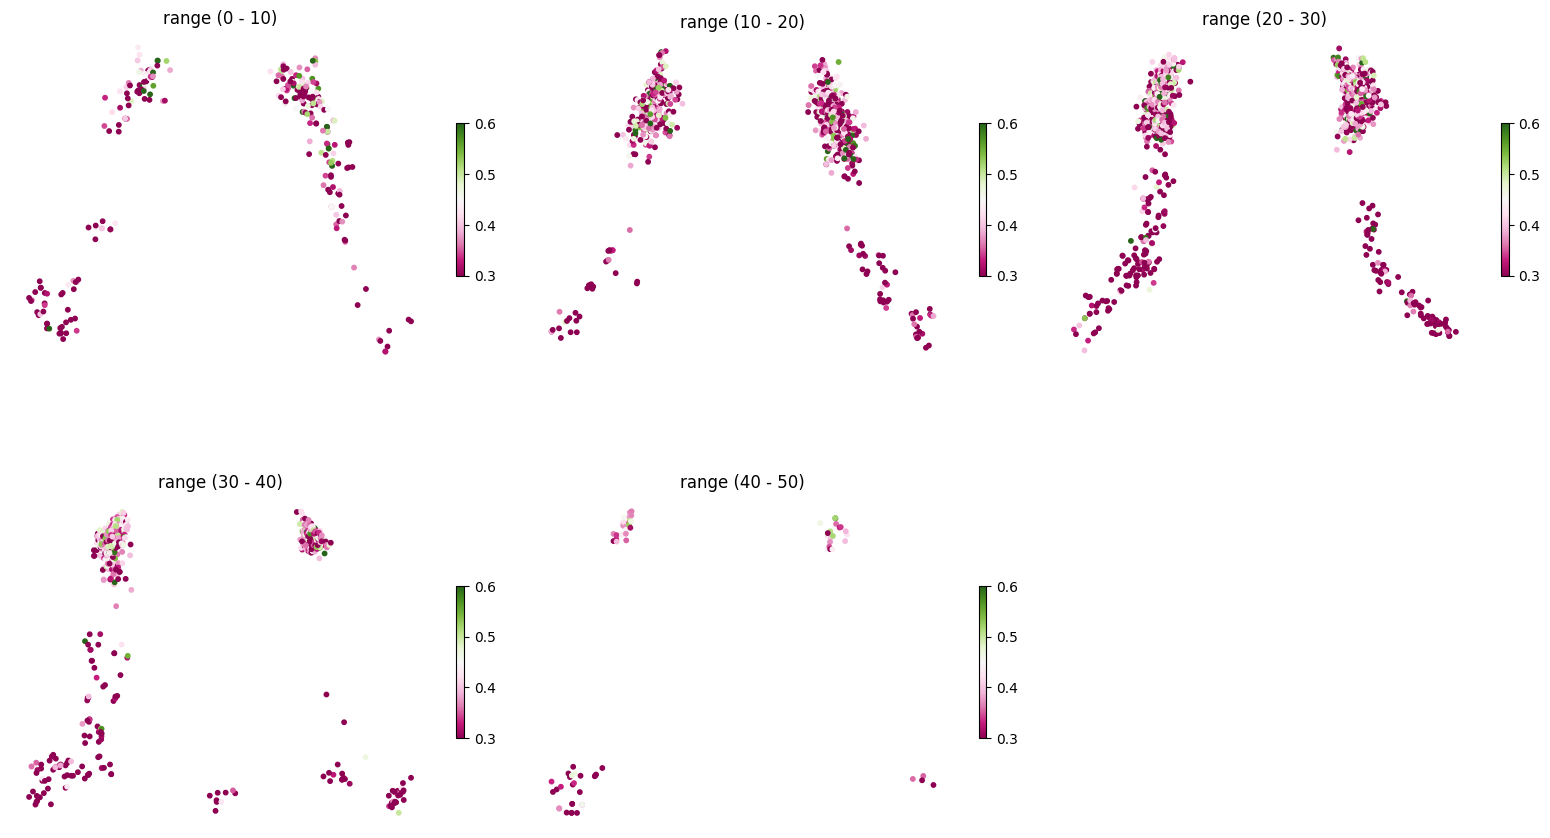

In [41]:
plt.figure(figsize = (16,10))
for q,z_min in enumerate(np.arange(0, df_merged['slice'].values.max(), step= 10)):
    mask = (df_merged['slice']>z_min)&(df_merged['slice']<=z_min+10)
    plt.subplot(2,3,q+1)
    plt.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask],
                c=df_merged['imputed pseudocluster'][mask], s=10, cmap ='PiYG', vmin = 0.3, vmax = 0.6)
    plt.gca().set_aspect('equal')
    plt.gca().invert_yaxis()
    plt.colorbar(shrink = .3)
    plt.axis('off')
    plt.title(f'range ({z_min} - {z_min+10})')
plt.tight_layout()    

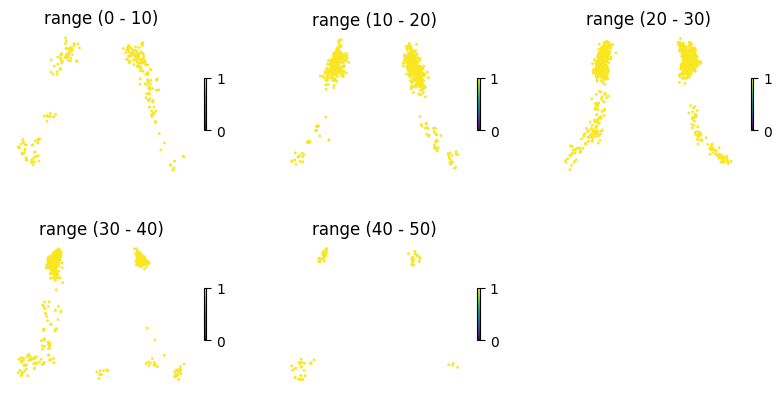

In [42]:
plt.figure(figsize = (10, 5))
for q,z_min in enumerate(np.arange(0, df_merged['slice'].values.max(), step= 10)):
    mask = (df_merged['slice']>z_min)&(df_merged['slice']<=z_min+10)
    plt.subplot(2,3,q+1)
    plt.scatter(df_merged['CCF_ML'][mask],df_merged['CCF_DV'][mask],
                c=df_merged['confidence_power'][mask], s=1, vmin = 0, vmax = 1)
    plt.gca().set_aspect('equal')
    plt.gca().invert_yaxis()
    plt.colorbar(shrink = .3)
    plt.axis('off')
    plt.title(f'range ({z_min} - {z_min+10})')

# diagnosis:
**understanding why ventral cells are more confident (i.e.,g shorter distance to snRNA cells than the dorsal cells)**

## (1) finding teh genes with high correlation to the confidence power

In [100]:
df_merged.shape, adata_bar.shape

((3442, 9), (3442, 29))

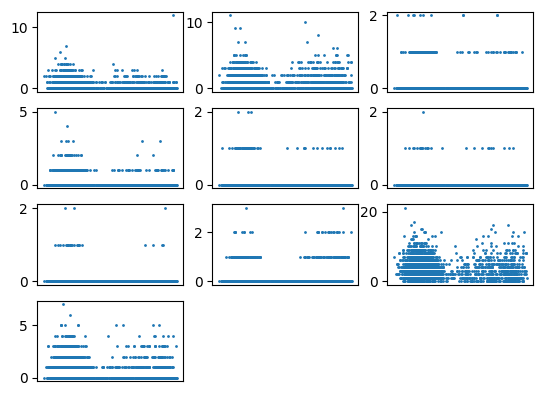

In [101]:
for g in range(10):
    plt.subplot(4,3,g+1)
    plt.scatter(df_merged['CCF_DV'],adata_bar.X[:,g],s=1)
    plt.gca().set_xticks([])

In [102]:
df_merged['CCF_DV'].shape

(3442,)

In [103]:
adata_bar.X.shape

(3442, 29)

In [104]:
from scipy.spatial import distance

In [105]:
def std_M(M):
    eps = 1e-12
    row_means = np.mean(M,1)[:,None]
    row_stds = np.std(M,1)[:,None] + eps
    std_M = (M - row_means) / row_stds 
    return(std_M)

In [106]:
adata_bar.X.shape

(3442, 29)

In [107]:
foo1 = std_M(adata_bar.X.copy())  # (3k x 100)
foo2 = np.array(df_merged['CCF_DV'])
foo3 = np.array(conf_bar['pscores'])

In [108]:
foo1c = foo1 - foo1.mean(axis=0)       # shape (3000, 100)
foo2c =  foo2 -  foo2.mean()           # shape (3000,)
foo3c =  foo3 -  foo3.mean()           # shape (3000,)



## (2) finding teh genes with high correlation to CCF_DV

In [109]:

# compute numerator: Xᵀ·y (dot products of each column with y)
num = foo1c.T @ foo2c               # shape (100,)
# compute denominator: ||Xc[:,i]|| * ||yc||
den = np.sqrt((foo1c**2).sum(axis=0) * (foo2c**2).sum())  # shape (100,)

corrs = num / den             # shape (100,)

# to see which feature is most correlated:
top_idx = np.argsort(corrs)[::-1]  # descending
for i in top_idx[:5]:
    print(f"feat_{i} ({adata_bar.var_names[i]}): r = {corrs[i]:.3f}")

feat_22 (Phox2b): r = 0.436
feat_28 (Tacr3): r = 0.412
feat_14 (Lmo3): r = 0.269
feat_27 (Tacr1): r = 0.197
feat_23 (Rgs2): r = 0.179


Text(0.5, 0.98, 'DV vs expression, colored by pscores')

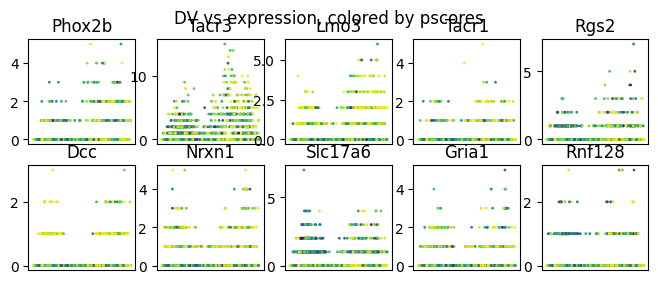

In [110]:
plt.figure(figsize = (8,3))
for k,g in enumerate(top_idx[:10]):
    plt.subplot(2,5,k+1)
    plt.scatter(df_merged['CCF_DV'],adata_bar[:,g].X,s=1, c = conf_bar['pscores'])
    plt.gca().set_xticks([])
    plt.title(adata_bar.var_names[g])
    
plt.suptitle('DV vs expression, colored by pscores')    

### for confidence scores

In [111]:

# compute numerator: Xᵀ·y (dot products of each column with y)
num = foo1c.T @ foo3c               # shape (100,)
# compute denominator: ||Xc[:,i]|| * ||yc||
den = np.sqrt((foo1c**2).sum(axis=0) * (foo3c**2).sum())  # shape (100,)

corrs = num / den             # shape (100,)

# to see which feature is most correlated:
top_idx = np.argsort(corrs)[::-1]  # descending
for i in top_idx[:5]:
    print(f"feat_{i} ({adata_bar.var_names[i]}): r = {corrs[i]:.3f}")

feat_1 (Calcr): r = 0.394
feat_19 (Nrxn1): r = 0.229
feat_14 (Lmo3): r = 0.187
feat_8 (Dlk1): r = 0.137
feat_7 (Dcc): r = 0.104


Text(0.5, 0.98, 'DV vs expression, colored by pscores')

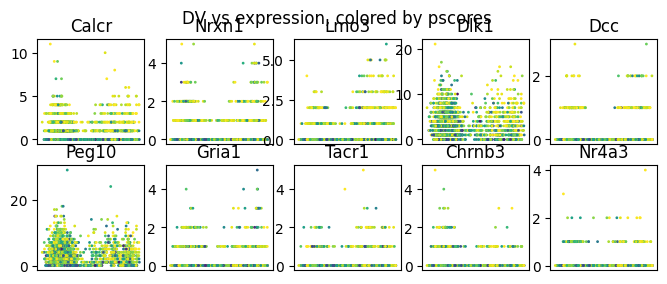

In [112]:
plt.figure(figsize = (8,3))
for k,g in enumerate(top_idx[:10]):
    plt.subplot(2,5,k+1)
    plt.scatter(df_merged['CCF_DV'],adata_bar[:,g].X,s=1, c = conf_bar['pscores'])
    plt.gca().set_xticks([])
    plt.title(adata_bar.var_names[g])
plt.suptitle('DV vs expression, colored by pscores')    

## (3) gene highly correlated with the pscoe is important. but what are their variances (and how does that relate to the snRNA part)

In [113]:
adata_sc.shape, adata_bar.shape

((4895, 2251), (3442, 29))

#### now overlay the genes that has super high correlation to the confidence power thingy 

Text(0.5, 0.98, 'DV vs expression, colored by pscores')

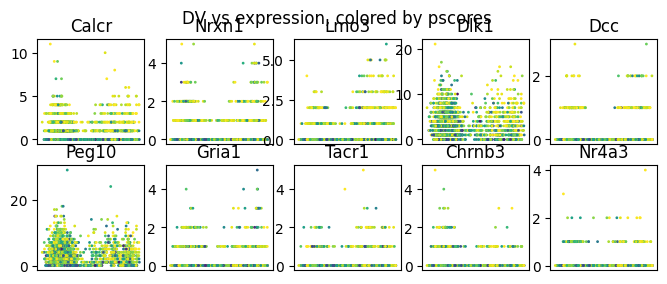

In [115]:
plt.figure(figsize = (8,3))
for k,g in enumerate(top_idx[:10]):
    plt.subplot(2,5,k+1)
    plt.scatter(df_merged['CCF_DV'],adata_bar[:,g].X,s=1, c = conf_bar['pscores'])
    plt.gca().set_xticks([])
    plt.title(adata_bar.var_names[g])
plt.suptitle('DV vs expression, colored by pscores')    

Text(0.5, 0.98, 'gene variance consistency ')

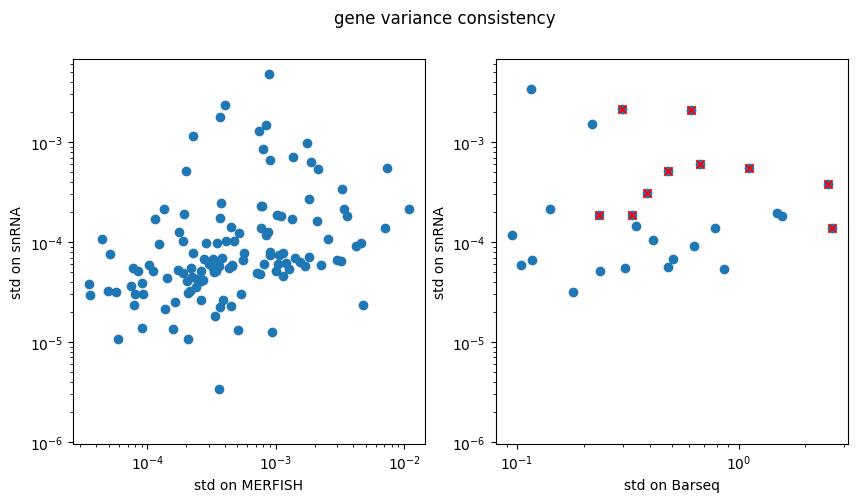

In [116]:

plt.figure(figsize = (10,5))
plt.subplot(1,2,1);plt.scatter(np.std(adata_mer[:,common_genes_mer].X,0),np.std(adata_sc[:,common_genes_mer].X,0), )
plt.ylim(np.std(adata_sc.X,0).min(),np.std(adata_sc.X,0).max())
plt.xscale('log');plt.yscale('log')
plt.ylabel('std on snRNA');plt.xlabel('std on MERFISH')
plt.subplot(1,2,2);plt.scatter(np.std(adata_bar[:,common_genes_bar].X,0), np.std(adata_sc[:,common_genes_bar].X,0), )
for g in top_idx[:10]:
    thisgene = adata_bar.var_names[g]
    plt.scatter(np.std(adata_bar.X[:,g]), np.std(adata_sc[:,thisgene].X), marker = 'x',color='red')    
plt.ylim(np.std(adata_sc.X,0).min(),np.std(adata_sc.X,0).max())
plt.ylabel('std on snRNA');plt.xlabel('std on Barseq')
plt.xscale('log');plt.yscale('log')
plt.suptitle('gene variance consistency ')

    
    

# we should sample the pair-wise distance for adata_bar where high confidence vs. low confidence next.

In [71]:
df_merged.head()

,Unnamed: 0,slice,barcode,uid,CCF_DV,CCF_ML,louvain_cluster,imputed pseudocluster,confidence_power
0,5_17_380460,17,0,5_17_380460,183.026557,185.603010,1,0.241148,0.845
1,5_17_380518,17,1,5_17_380518,177.716705,186.262665,2,0.404162,0.733
2,5_17_380548,17,1,5_17_380548,176.795441,187.163641,1,0.227864,0.588
3,5_17_380660,17,0,5_17_380660,171.708297,189.205095,1,0.427332,0.793
4,5_17_380687,17,0,5_17_380687,180.587447,190.182430,2,0.490295,0.747


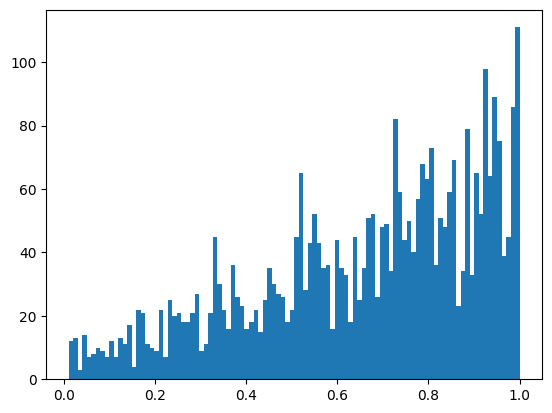

In [72]:
plt.hist(df_merged['confidence_power'],bins = 100);

In [74]:
group1mask = df_merged['confidence_power']>0.7
adata_bar[group1mask].shape, adata_bar[~group1mask].shape, adata_bar.shape

((1797, 102), (1645, 102), (3442, 102))

# create a null distributions between 

In [76]:
def create_null_dst(adata_ref, adata_query):
    common_genes = np.intersect1d(adata_query.var_names, adata_ref.var_names)
    X_ref = adata_ref[:, common_genes].X
    X_q = adata_query[:, common_genes].X     
    X_ref_norm = processing.rankrows(X_ref,standardize = True)
    X_q_norm = processing.rankrows(X_q,standardize = True)
    _,d_rand = compute_baseline_distance_between(X_ref_norm, X_q_norm, n_pairs=1000, random_state=42) 
    return(d_rand)
    

In [85]:
group1_null=create_null_dst(adata_sc, adata_bar[group1mask])
group2_null=create_null_dst(adata_sc, adata_bar[~group1mask])
mer_null=create_null_dst(adata_sc, adata_mer)

Text(0.5, 0, 'random pair (btw barseq and snRNA) distances')

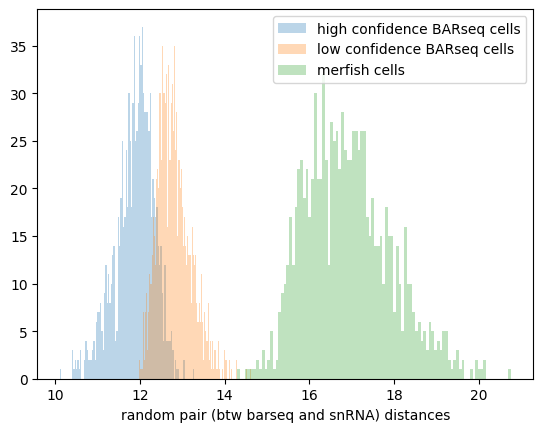

In [86]:
plt.hist(group1_null,bins = 100,alpha =.3, label ='high confidence BARseq cells');
plt.hist(group2_null,bins = 100,alpha =.3, label ='low confidence BARseq cells');
plt.hist(mer_null,bins = 100,alpha =.3, label ='merfish cells');
plt.legend()
plt.xlabel('random pair (btw barseq and snRNA) distances')

# test with varying num of merfish data

In [39]:
from scipy.stats import gaussian_kde

In [40]:
from scipy import sparse 
if sparse.issparse(adata_mer.X):
    X = adata_mer.X.toarray()
else:
    X = adata_mer.X
gene_vars = X.var(axis=0)

idx_sorted = np.argsort(gene_vars)
least_idx = idx_sorted[:100]            # 100 smallest variances
most_idx  = idx_sorted[-100:]           # 100 largest variances

# 100 random genes (fix seed for reproducibility)
rng = np.random.default_rng(42)
rand_idx = rng.choice(X.shape[1], size=100, replace=False)

genes_least  = adata_mer.var_names[least_idx]
genes_most   = adata_mer.var_names[most_idx]
genes_random = adata_mer.var_names[rand_idx]

adata_least  = adata_mer[:, genes_least].copy()
adata_most   = adata_mer[:, genes_most].copy()
adata_random = adata_mer[:, genes_random].copy()


In [41]:
datlist =[adata_least,adata_most,adata_random]

In [42]:
datlist = dict()
datlist['least var'] = adata_least
datlist['most var'] = adata_most
datlist['random'] = adata_random

using 100 genes to run the imputations!
using 100 genes to run the imputations!
using 100 genes to run the imputations!


Text(0.5, 1.0, 'num of nbrs: 100')

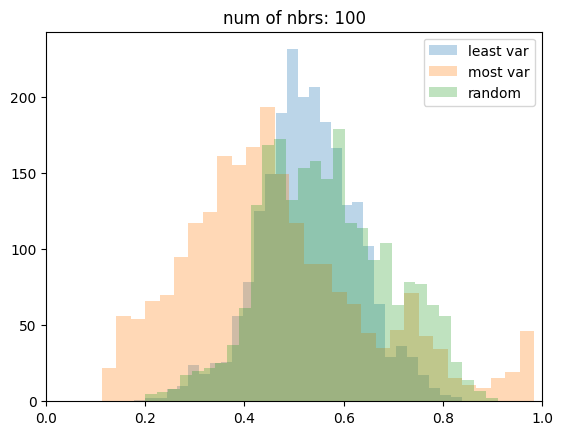

In [43]:
k = 100
implist =dict()
conflist =dict()
for key,adata in datlist.items():
    imp,conf = impute_pseudocluster(adata, adata_sc,k=k)
    implist[key] = imp
    conflist[key] = conf
    plt.hist(implist[key], bins = 30,alpha = .3, label = key);
    plt.legend()
    plt.xlim(0,1)
plt.title(f'num of nbrs: {k}')


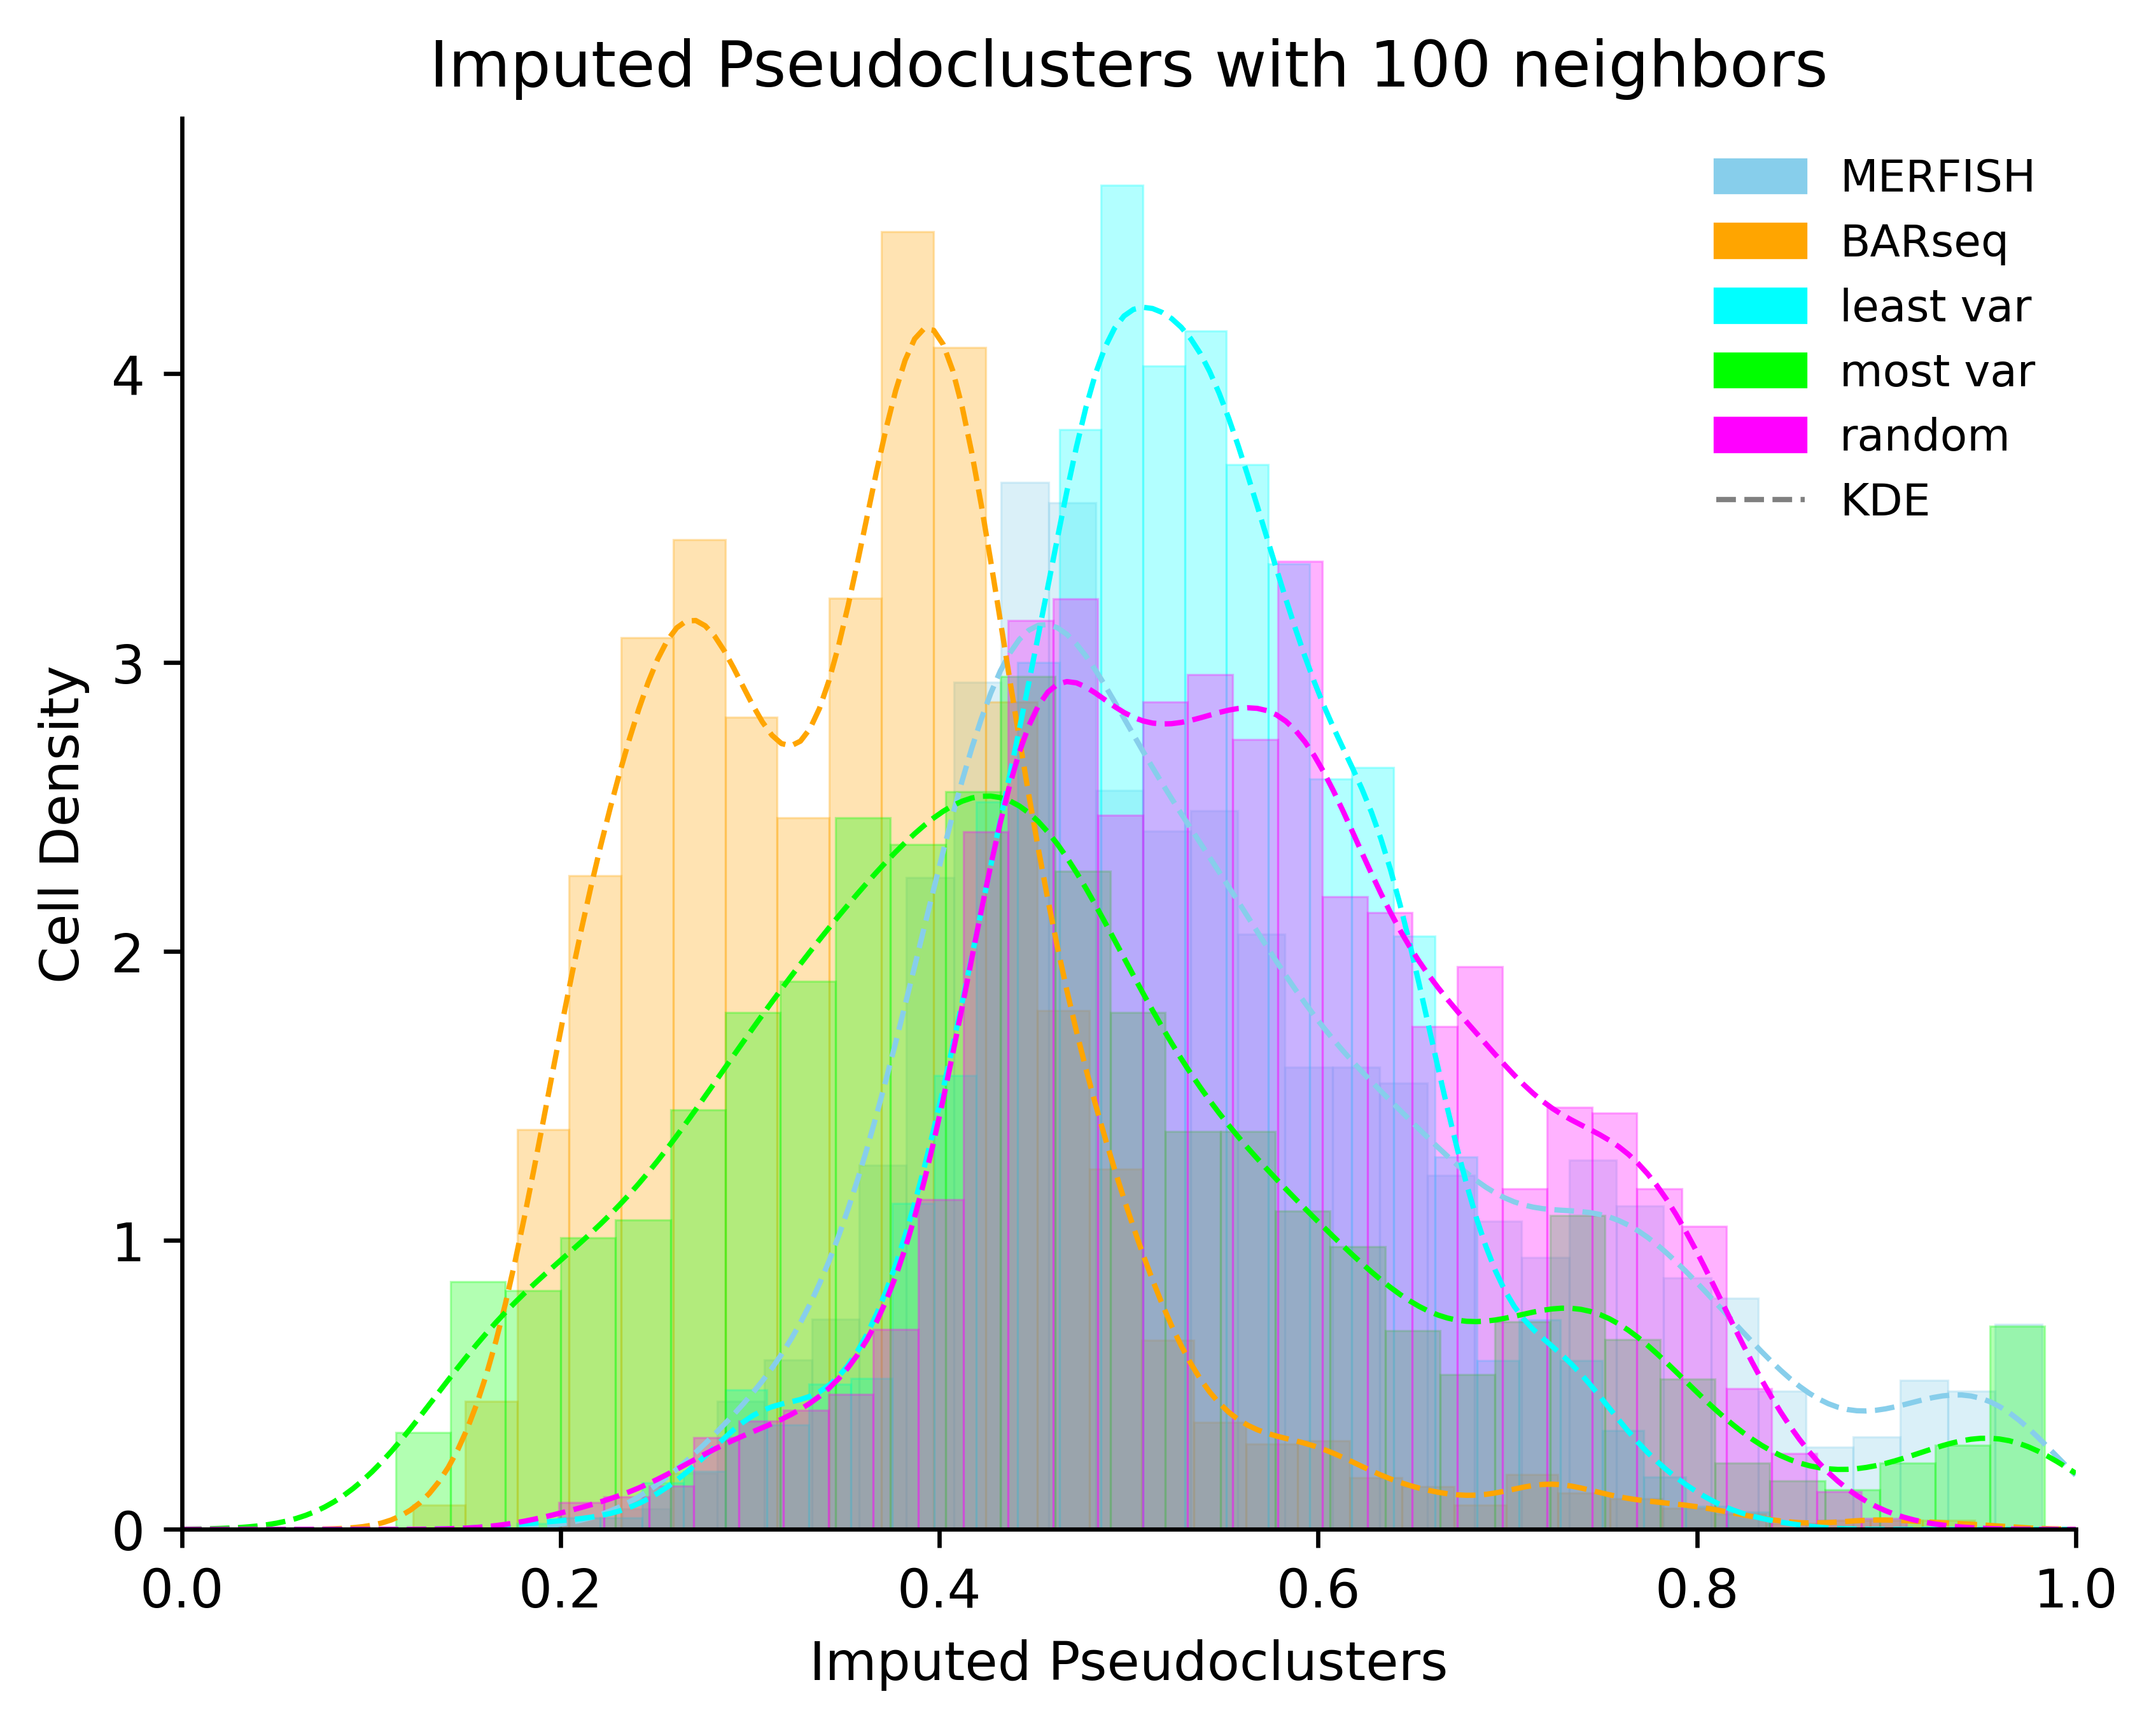

In [44]:
bins = 30
x_grid = np.linspace(0, 1, 200)
plt.hist(imp_mer, bins = bins,alpha = .3, density = True,
         linewidth=0.4,label = 'Original MERFISH',color='skyblue',edgecolor='skyblue');
kde_mer = gaussian_kde(imp_mer)
plt.plot(x_grid,kde_mer(x_grid), linestyle='--',linewidth=1,color='skyblue',label=f'Original MERFISH KDE')

plt.hist(imp_bar, bins = bins,alpha = .3, density = True,
         linewidth=0.4,label = 'Original BARseq',color='orange',edgecolor='orange');
kde_bar = gaussian_kde(imp_bar)
plt.plot(x_grid,kde_bar(x_grid),linestyle='--',linewidth=1,color='orange',label=f'Original BARseq KDE')

collist = ['cyan','lime','magenta']
bin_edges = np.linspace(0, 1, bins+1)
bin_width = bin_edges[1] - bin_edges[0]
from scipy.stats import gaussian_kde 

for q,(key,adata) in enumerate(datlist.items()):
    plt.hist(implist[key], bins = bins,alpha = .3, edgecolor=collist[q],color=collist[q],
             linewidth=0.4,density = True,
             label = key);
    
    x_grid = np.linspace(0, 1, 200)
    kde = gaussian_kde(implist[key])
    plt.plot(
        x_grid,kde(x_grid),#*len(implist[key])*bin_width,
        linestyle='--',linewidth=1,color=collist[q],
        label=f'{key} KDE')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
hist_handles = [
    Patch(facecolor='skyblue', edgecolor='skyblue', label='MERFISH'),
    Patch(facecolor='orange', edgecolor='orange', label='BARseq'),
]
for col, key in zip(collist, datlist.keys()):
    hist_handles.append(
        Patch(facecolor=col, edgecolor=col, label=key))

kde_handle = Line2D([0], [0], color='gray', linestyle='--',
                    linewidth=1, label='KDE')

plt.legend(
    handles=hist_handles + [kde_handle],
    ncol=1,
    fontsize='small',
    frameon=False)

plt.xlim(0,1)
plt.title(f'Imputed Pseudoclusters with {k} neighbors')
plt.ylabel('Cell Density')
plt.xlabel('Imputed Pseudoclusters')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gcf().set_dpi(600)

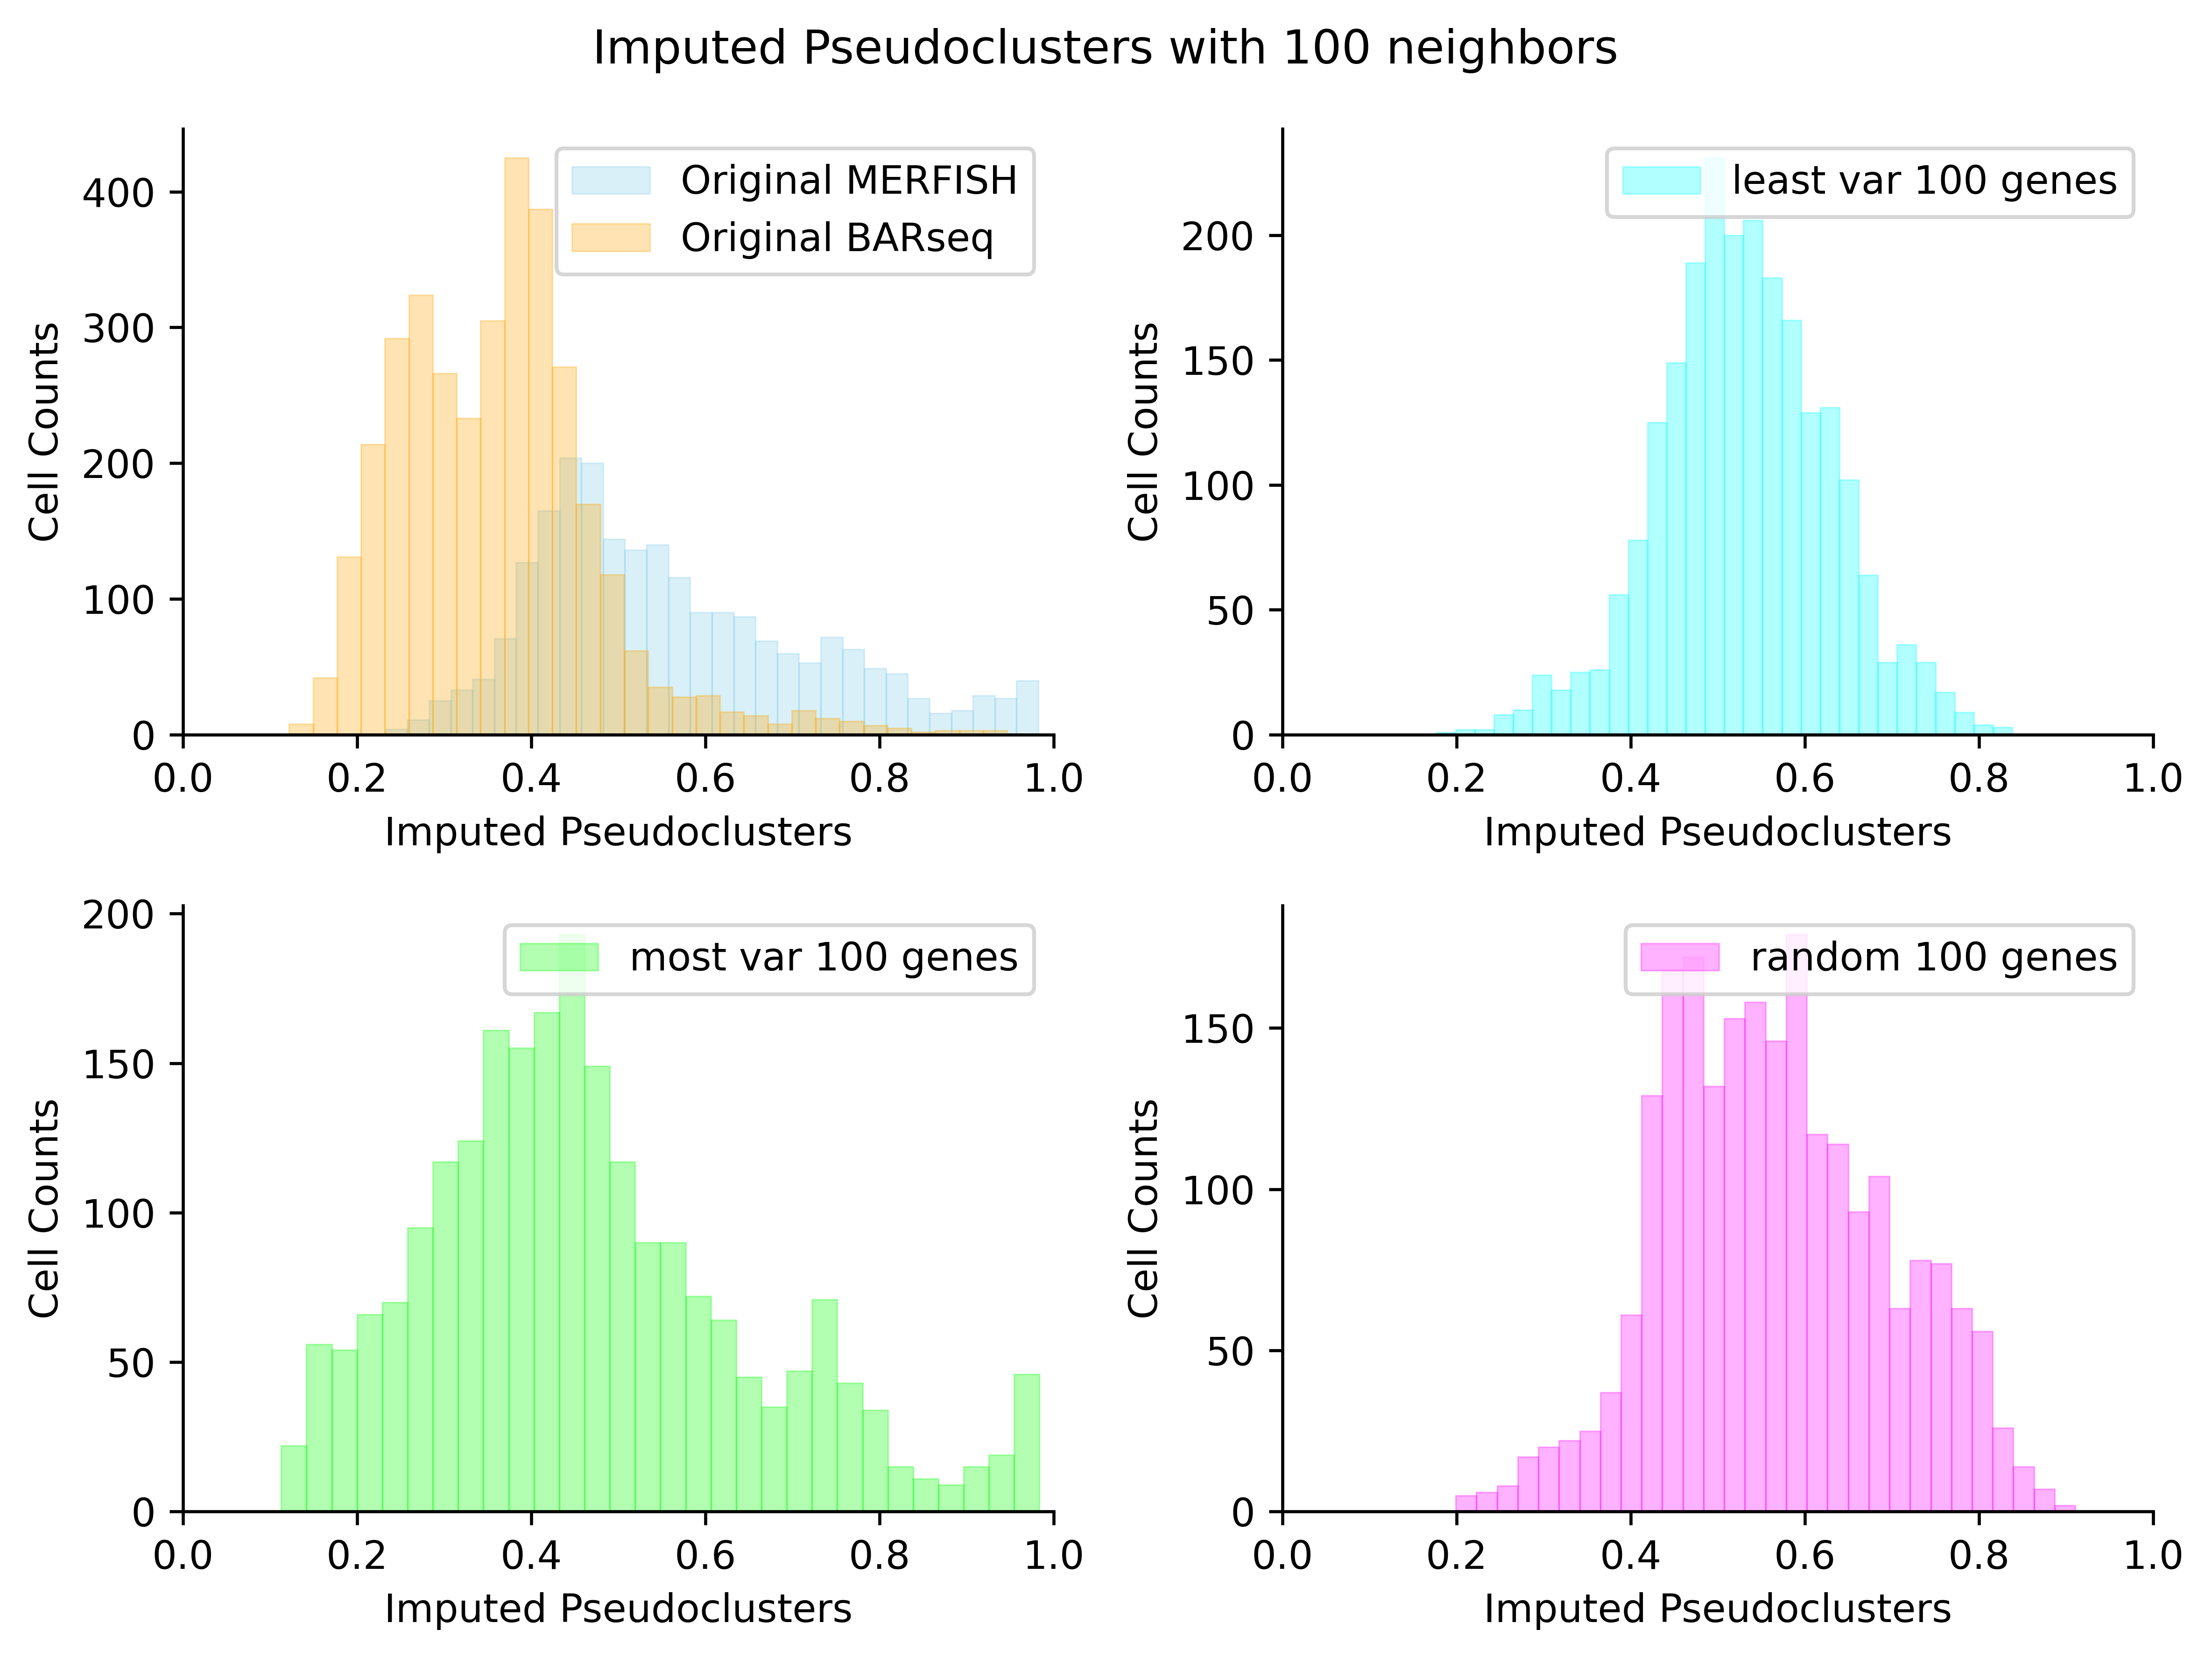

In [45]:
bins = 30
plt.figure(figsize = (8,6))
plt.subplot(2,2,1)
plt.hist(imp_mer, bins = bins,alpha = .3, density = False,
         linewidth=0.4,label = 'Original MERFISH',color='skyblue',edgecolor='skyblue');
plt.hist(imp_bar, bins = bins,alpha = .3, density = False,
         linewidth=0.4,label = 'Original BARseq',color='orange',edgecolor='orange');
plt.legend()
plt.ylabel('Cell Counts')
plt.xlabel('Imputed Pseudoclusters')
plt.xlim(0,1)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

collist = ['cyan','lime','magenta']
bin_edges = np.linspace(0, 1, bins+1)
bin_width = bin_edges[1] - bin_edges[0]

for q,(key,adata) in enumerate(datlist.items()):
    plt.subplot(2,2,q+2)
    plt.hist(implist[key], bins = bins,alpha = .3, edgecolor=collist[q],color=collist[q],
             linewidth=0.4,density = False,
             label = key+ ' 100 genes');
    plt.legend()
    plt.ylabel('Cell Counts')
    plt.xlabel('Imputed Pseudoclusters')
    plt.xlim(0,1)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)

plt.suptitle(f'Imputed Pseudoclusters with {k} neighbors')
plt.tight_layout()
plt.gcf().set_dpi(600)

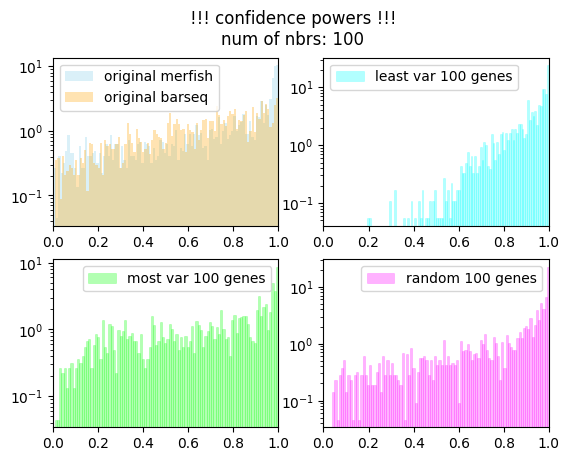

In [46]:
bins = 100
plt.subplot(2,2,1)
plt.hist(conf_mer['pscores'], bins = bins,alpha = .3, density = True,label = 'original merfish',color='skyblue');
plt.hist(conf_bar['pscores'], bins = bins,alpha = .3, density = True,label = 'original barseq',color='orange');
plt.yscale('log')
plt.legend()
plt.xlim(0,1)

x_grid = np.linspace(0, 1, 200)
kde_mer = gaussian_kde(conf_mer['pscores'])
kde_bar = gaussian_kde(conf_bar['pscores'])

collist = ['cyan','lime','magenta']
bin_edges = np.linspace(0, 1, bins+1)
bin_width = bin_edges[1] - bin_edges[0]
from scipy.stats import gaussian_kde 

for q,(key,adata) in enumerate(datlist.items()):
    plt.subplot(2,2,q+2)
    plt.hist(conflist[key]['pscores'], bins = bins,alpha = .3, edgecolor=collist[q],color=collist[q],
             linewidth=0.4,density = True,label = key+ ' 100 genes');
    plt.legend()
    plt.yscale('log')
    plt.xlim(0,1)
plt.suptitle(f'!!! confidence powers !!!\nnum of nbrs: {k}');
